#### Abstract

This notebook addresses missing value handling for our flight traces time series data. Missing values are cleansed on a per-flight-id basis using linear interpolation, forward and backward fill, ensuring that interpolation boundaries remain strictly within individual flight trajectories.

This grouping strategy prevents cross-flight information leakage, as no values are inferred from neighboring flights or from the test set. The choice to perform this step before splitting is justified by the sample-level independence of each flight: since interpolation operates solely within a single flight's temporal window, no statistical information crosses the train-test boundary. The resulting dataset is free of missing values and ready for feature extraction and subsequent model training.

In [199]:

from paths import *
import pandas as pd
import duckdb

from src.common.plots import *
from src.common.data_integrity import *

In [200]:
CRASH_PATH  = PARQUET_TRACES_CRASH / "traces_00.pq"

#### Schema Analysis

In [201]:
con = duckdb.connect()
crashes = con.execute(f"SELECT * FROM parquet_scan('{CRASH_PATH}')").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [202]:
print(con.sql(f"DESCRIBE SELECT  * FROM parquet_scan('{CRASH_PATH}')").df())

    column_name                                        column_type null   key  \
0       dbFlags                                             BIGINT  YES  None   
1          desc                                            VARCHAR  YES  None   
2          icao                                            VARCHAR  YES  None   
3             r                                            VARCHAR  YES  None   
4   reg_details  STRUCT(description VARCHAR, iso2 VARCHAR, iso3...  YES  None   
5             t                                            VARCHAR  YES  None   
6     timestamp                                            VARCHAR  YES  None   
7         trace  STRUCT(aircraft STRUCT(alert BIGINT, alt_geom ...  YES  None   
8       version                                            VARCHAR  YES  None   
9         ownOp                                            VARCHAR  YES  None   
10         year                                            VARCHAR  YES  None   

   default extra  
0     No

The schema has 11 columns total, where most are simple VARCHAR/BIGINT metadata fields about the aircraft, like icao (unique hex ID), r (tail number), t (type code), desc (model name), ownOp (operator) and year (manufacture year). The two nested STRUCTs are where it gets interesting: reg_details holds country/category registration info, while trace is the core of the dataset containing the full aircraft state per position update (altitude, speed, heading, lat/lon, and ADS-B quality indicators). Worth noting that version, ownOp and year already showed significant null rates, so those need extra attention during the quality checks.

In [203]:
crashes.head()

,dbFlags,desc,icao,r,reg_details,t,timestamp,trace,version,ownOp,year
0,0,BEECH 1900,00a61a,ZS-OKN,"{'description': 'general', 'iso2': 'ZA', 'iso3...",B190,2023-11-01 00:00:00+00:00,"{'aircraft': {'alert': 0, 'alt_geom': 9625.0, ...",NaN,NaN,NaN
1,0,BEECH 1900,00a61a,ZS-OKN,"{'description': 'general', 'iso2': 'ZA', 'iso3...",B190,2023-11-01 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",NaN,NaN,NaN
2,0,BEECH 1900,00a61a,ZS-OKN,"{'description': 'general', 'iso2': 'ZA', 'iso3...",B190,2023-11-01 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",NaN,NaN,NaN
3,0,BEECH 1900,00a61a,ZS-OKN,"{'description': 'general', 'iso2': 'ZA', 'iso3...",B190,2023-11-01 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",NaN,NaN,NaN
4,0,BEECH 1900,00a61a,ZS-OKN,"{'description': 'general', 'iso2': 'ZA', 'iso3...",B190,2023-11-01 00:00:00+00:00,"{'aircraft': {'alert': 0, 'alt_geom': 9675.0, ...",NaN,NaN,NaN


In [204]:
crashes.info()

<class 'pandas.DataFrame'>
RangeIndex: 961727 entries, 0 to 961726
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   dbFlags      961727 non-null  int64 
 1   desc         939535 non-null  str   
 2   icao         961727 non-null  str   
 3   r            961727 non-null  str   
 4   reg_details  957737 non-null  object
 5   t            961727 non-null  str   
 6   timestamp    961727 non-null  str   
 7   trace        961727 non-null  object
 8   version      366877 non-null  str   
 9   ownOp        668386 non-null  str   
 10  year         643518 non-null  str   
dtypes: int64(1), object(2), str(8)
memory usage: 157.4+ MB


In [205]:
con.execute(f"SELECT typeof(trace) FROM read_parquet('{CRASH_PATH}') LIMIT 1").df()

,typeof(trace)
0,"STRUCT(aircraft STRUCT(alert BIGINT, alt_geom ..."


Dataset structure:

Each row represents a single trace point (snapshot every few seconds) of a flight.
A unique flight is identified by 'icao' + 'timestamp' (date), with the exact position/speed/altitude data nested inside the 'trace' column. There are also other identifier like registration.

Let's find out how many airplanes we have in the accident dataset approximately.

In [206]:
crashes['timestamp'] = pd.to_datetime(crashes['timestamp'])
crashes['year_flight'] = crashes['timestamp'].dt.year
crashes['day'] = crashes['timestamp'].dt.day

In [207]:
print(f"Unique aircraft: {crashes['icao'].nunique()}")
print(f"Unique flights (icao + day): {crashes.groupby(['icao', 'day']).ngroups}")

Unique aircraft: 219
Unique flights (icao + day): 519


We have around 220 unique aircraft and ~520 unique icao-day combinations in our dataset.

#### Trace Struct-Field Analysis

In [208]:
con.execute(f"SELECT trace.* FROM read_parquet('{CRASH_PATH}') LIMIT 1").df()

,aircraft,altitude,flags,geometric_altitude,geometric_vertical_rate,ground_speed,h3_5,indicated_airspeed,lat,lon,roll_angle,source,timestamp,track_degrees,vertical_rate
0,"{'alert': 0, 'alt_geom': 9625.0, 'baro_rate': ...",9000.0,5,9625.0,-192.0,230.2,85bcc343fffffff,<NA>,-26.052933,28.025605,NaN,adsb_icao,2023-11-01 05:32:13.070000+00:00,162.0,-192.0


In [209]:
con.execute(f"SUMMARIZE SELECT trace.* FROM read_parquet('{CRASH_PATH}')").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,aircraft,"STRUCT(alert BIGINT, alt_geom DOUBLE, baro_rat...","{'alert': 0, 'alt_geom': -2675.0, 'baro_rate':...","{'alert': NULL, 'alt_geom': NULL, 'baro_rate':...",243089,NaN,NaN,NaN,NaN,NaN,961727,0.00
1,altitude,DOUBLE,-650.0,44500.0,1467,19709.961251933917,13738.758348863983,6020.282452279019,18582.915579922195,34031.94505366173,961727,10.55
2,flags,BIGINT,0,13,11,0.3102803602269667,1.0405901911454694,0,0,0,961727,0.00
3,geometric_altitude,DOUBLE,-2725.0,45450.0,1732,19985.668983125262,14278.124605555038,5775.3335175803,18712.152244156,34971.10408398505,961727,10.24
4,geometric_vertical_rate,DOUBLE,-21632.0,17408.0,538,100.57665263978704,1456.9082274429734,-822.1493548337806,0.0,865.7346370985867,961727,61.33
5,ground_speed,DOUBLE,0.0,4380.0,4602,311.4261729907795,151.94062225073782,205.32831027220448,335.651112838546,440.233369984284,961727,1.06
6,h3_5,VARCHAR,85062927fffffff,85c9926ffffffff,63486,NaN,NaN,NaN,NaN,NaN,961727,0.00
7,indicated_airspeed,BIGINT,50,660,309,246.48758843221066,44.688862000418865,224,254,275,961727,69.03
8,lat,DOUBLE,-39.678406,69.739105,778825,37.67050407095352,15.109615536716477,34.250400675058714,39.67023428325633,44.37901025799294,961727,0.00
9,lon,DOUBLE,-174.960846,178.938924,1080629,-51.372734082983975,68.99757665123148,-96.52646028713625,-79.81960626471668,0.12244584822285659,961727,0.00


The accident-specific dataset contains ~920K ADS-B trace points from March 2023 to January 2026, with:

- Spatial coverage across latitudes from -39.7° to 69.7° and the full longitude range — broad but less global than the random dataset (concentrated more in northern hemisphere)
- Altitudes from -650 to 44,500 ft (avg ~19,700 ft, median ~18,500 ft) — average slightly higher than random dataset, max within realistic commercial ceiling
- Ground speeds from 0 to 4,380 knots (avg ~315 knots) — average matches commercial cruise, max is an outlier (typical commercial ~500–600 knots)
- Track headings covering the full 0–360° range (avg ~181°) — evenly distributed
- Vertical rates from -23,744 to +20,032 ft/min (avg ~129 ft/min) — average close to zero, extreme min/max values are outliers (realistic range ±6,000 ft/min)
- Roll angles between -24.8° and +27.6° (avg ~0°) — all within typical flight envelope
- 4 different source types (from `adsb_icao` to `tisb_icao`) — standard ADS-B receiver mix
- H3 hexagonal spatial index (resolution 5) with ~58k unique cells covered — smaller footprint than random dataset, as expected for fewer flights

Flags field defintion from ADS-Exchange (https://www.adsbexchange.com/version-2-api-wip/)

flags are a bitfield: (use bitwise and to extract data) 
- (flags & 1 > 0): position is stale (no position received for 20 seconds before this one)
- (flags & 2 > 0): start of a new leg (tries to detect a separation point between landing and takeoff that separates flights)
- (flags & 4 > 0): vertical rate is geometric and not barometric
- (flags & 8 > 0): altitude is geometric and not barometric ADS-B Exchange

##### Null-Values Analysis

In [210]:
con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    ROUND(SUM(CASE WHEN trace.altitude                IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_altitude,
    ROUND(SUM(CASE WHEN trace.ground_speed            IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_ground_speed,
    ROUND(SUM(CASE WHEN trace.track_degrees           IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_track_degrees,
    ROUND(SUM(CASE WHEN trace.vertical_rate           IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_vertical_rate,
    ROUND(SUM(CASE WHEN trace.geometric_altitude      IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_geometric_altitude,
    ROUND(SUM(CASE WHEN trace.geometric_vertical_rate IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_geom_vrate,
    ROUND(SUM(CASE WHEN trace.indicated_airspeed      IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_ias,
    ROUND(SUM(CASE WHEN trace.roll_angle              IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_roll,
    ROUND(SUM(CASE WHEN trace.lat                     IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_lat,
    ROUND(SUM(CASE WHEN trace.lon                     IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_lon,
    ROUND(SUM(CASE WHEN trace.source                  IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_null_source
FROM parquet_scan('{CRASH_PATH}')
""").df()

,total_rows,pct_null_altitude,pct_null_ground_speed,pct_null_track_degrees,pct_null_vertical_rate,pct_null_geometric_altitude,pct_null_geom_vrate,pct_null_ias,pct_null_roll,pct_null_lat,pct_null_lon,pct_null_source
0,961727,10.55,1.06,2.62,9.96,10.24,61.33,69.03,70.47,0.0,0.0,0.0


- lat/lon/source: 0% nulls ✅ — position data is always present
- altitude / geometric_altitude / vertical_rate: ~10% nulls ✅ — very solid, but not perfect
- ground_speed/track_degrees: 1-2% nulls ✅ — very good
- geometric_vertical_rate: 63% null 🟡 
- indicated_airspeed/roll_angle: 71-72% null 🟡 

##### Duplicate Check

In [211]:
con.sql(f"""
SELECT
    COUNT(*)                                                    AS total_rows,
    COUNT(*) - COUNT(DISTINCT (icao, trace.timestamp))          AS duplicate_rows,
    (COUNT(*) - COUNT(DISTINCT (icao, trace.timestamp))) * 100.0 / COUNT(*) AS pct_duplicates
FROM parquet_scan('{CRASH_PATH}')
""").df()

,total_rows,duplicate_rows,pct_duplicates
0,961727,1695,0.176245


Sources Duplicate combinations

In [212]:
con.sql(f"""
WITH dups AS (
    SELECT icao, trace.timestamp AS ts
    FROM parquet_scan('{CRASH_PATH}')
    GROUP BY icao, trace.timestamp
    HAVING COUNT(*) > 1
)
SELECT p.trace.source, COUNT(*) AS n
FROM parquet_scan('{CRASH_PATH}') p
JOIN dups ON p.icao = dups.icao AND p.trace.timestamp = dups.ts
GROUP BY p.trace.source
ORDER BY n DESC
""").df()

,source,n
0,adsb_icao,3263
1,tisb_icao,118
2,mlat,3
3,adsr_icao,2


We checked for duplicate rows based on `icao` + `trace.timestamp`. Only **0.2%** were flagged as duplicates. Breaking down by source, the majority come from `adsb_icao` (3,263), with smaller counts from `tisb_icao` (118), `mlat` (3), and `adsr_icao` (2). These are **near-duplicates**. Multiple receivers reporting the same signal with micro-level positional differences (6th decimal place ≈ ~10cm). Given the negligible share and the explainable cause, we will just delete these duplicate rows later, when creating our final datasets for anomaly detection.

#### Filtering accident traces

Goal: Analyze aircraft accidents by extracting the flight behavior shortly before each crash from ADS-B data.

Current status: The accidents CSV has been cleaned and all UTC timestamps validated.

Next step: For each accident, we filter the large ADS-B DuckDB table by ICAO match and a time window of T₀ − 120min to T₀ + 10min around the crash time, then unnest the trace struct to get clean per-accident trajectories.

In [213]:
from src.common.data_io import *
asn_accidents = import_df(ASN_DIR, "asn_accidents_final_filtered.csv")
asn_accidents.head(5)

,date,date_utc,time,time_utc,type,owner/operator,icao,registration,msn,year of manufacture,...,nature,departure airport,destination airport,investigating agency,confidence rating,narrative,record_id,record_url,total airframe hrs,cycles
0,Tuesday 21 March 2023,2023-03-21,15:23 LT,22:23,Boeing 777-224ER,United Airlines,aaba9a,N79011,29859/227,1999.0,...,Passenger - Scheduled,"San Francisco International Airport, CA (SFO/K...",MÃ¼nchen-Franz Josef Strauss Airport (MUC/EDDM),NTSB,Accident investigation report completed and in...,United Airlines flight UA194 encountered conve...,309736,https://aviation-safety.net/wikibase/309736,101792 hours,NaN
1,Wednesday 22 March 2023,2023-03-22,17:26 LT,22:26,Airbus A320-232,United Airlines,a16adc,N1902U,2714,2006.0,...,Passenger - Scheduled,Mexico City-Benito JuÃ¡rez International Airpo...,"Houston-George Bush Intercontinental Airport, ...",NTSB,Accident investigation report completed and in...,United Airlines flight UA1091 sustained a tail...,311365,https://aviation-safety.net/wikibase/311365,22194 hours,NaN
2,Wednesday 22 March 2023,2023-03-21,04:53 LT,19:53,Boeing 777-28EER,Asiana Airlines,71c254,HL8254,40198/1027,2012.0,...,Passenger - Scheduled,"Sydney-Kingsford Smith International Airport, ...",Seoul-Incheon International Airport (ICN/RKSI),ARAIB,Information verified through data from acciden...,"Asiana Airlines flight OZ602, a Boeing 777-28E...",311482,https://aviation-safety.net/wikibase/311482,NaN,NaN
3,Friday 24 March 2023,2023-03-24,10:15,16:15,McDonnell Douglas MD-88 (SF),USA Jet Airlines,ab6909,N834US,53259/1849,1991.0,...,Cargo,"Detroit-Willow Run Airport, MI (YIP/KYIP)",Saltillo-Plan de Guadalupe International Airpo...,NTSB,Accident investigation report completed and in...,"USA Jet Airlines, flight JUS834, sustained a t...",311093,https://aviation-safety.net/wikibase/311093,NaN,NaN
4,Sunday 9 April 2023,2023-04-09,17:29,16:29,Boeing 737-8AS (WL),Ryanair,4ca264,EI-DHH,33817/1677,2005.0,...,Passenger - Scheduled,Liverpool-John Lennon International Airport (L...,Dublin Airport (DUB/EIDW),AAIU,Accident investigation report completed and in...,"Ryanair flight FR5542, a Boeing 737-8AS, suffe...",310217,https://aviation-safety.net/wikibase/310217,NaN,NaN


In [214]:
icao_traces_list = con.sql(f"""
SELECT DISTINCT icao
FROM parquet_scan('{CRASH_PATH}')
ORDER BY icao
""").df()["icao"]
len(icao_traces_list)

219

In [215]:
icao_traces_list

0      00a61a
1      00b02e
2      06a07b
3      06a2f0
4      09c028
        ...  
214    e495a7
215    e49b02
216    e80246
217    e8044b
218    e8044f
Name: icao, Length: 219, dtype: str

In [216]:
asn_accidents_filtered = asn_accidents[
    asn_accidents['icao'].str.lower().isin(icao_traces_list)
]

In [217]:
asn_accidents_filtered.head(5)

,date,date_utc,time,time_utc,type,owner/operator,icao,registration,msn,year of manufacture,...,nature,departure airport,destination airport,investigating agency,confidence rating,narrative,record_id,record_url,total airframe hrs,cycles
0,Tuesday 21 March 2023,2023-03-21,15:23 LT,22:23,Boeing 777-224ER,United Airlines,aaba9a,N79011,29859/227,1999.0,...,Passenger - Scheduled,"San Francisco International Airport, CA (SFO/K...",MÃ¼nchen-Franz Josef Strauss Airport (MUC/EDDM),NTSB,Accident investigation report completed and in...,United Airlines flight UA194 encountered conve...,309736,https://aviation-safety.net/wikibase/309736,101792 hours,NaN
1,Wednesday 22 March 2023,2023-03-22,17:26 LT,22:26,Airbus A320-232,United Airlines,a16adc,N1902U,2714,2006.0,...,Passenger - Scheduled,Mexico City-Benito JuÃ¡rez International Airpo...,"Houston-George Bush Intercontinental Airport, ...",NTSB,Accident investigation report completed and in...,United Airlines flight UA1091 sustained a tail...,311365,https://aviation-safety.net/wikibase/311365,22194 hours,NaN
2,Wednesday 22 March 2023,2023-03-21,04:53 LT,19:53,Boeing 777-28EER,Asiana Airlines,71c254,HL8254,40198/1027,2012.0,...,Passenger - Scheduled,"Sydney-Kingsford Smith International Airport, ...",Seoul-Incheon International Airport (ICN/RKSI),ARAIB,Information verified through data from acciden...,"Asiana Airlines flight OZ602, a Boeing 777-28E...",311482,https://aviation-safety.net/wikibase/311482,NaN,NaN
3,Friday 24 March 2023,2023-03-24,10:15,16:15,McDonnell Douglas MD-88 (SF),USA Jet Airlines,ab6909,N834US,53259/1849,1991.0,...,Cargo,"Detroit-Willow Run Airport, MI (YIP/KYIP)",Saltillo-Plan de Guadalupe International Airpo...,NTSB,Accident investigation report completed and in...,"USA Jet Airlines, flight JUS834, sustained a t...",311093,https://aviation-safety.net/wikibase/311093,NaN,NaN
4,Sunday 9 April 2023,2023-04-09,17:29,16:29,Boeing 737-8AS (WL),Ryanair,4ca264,EI-DHH,33817/1677,2005.0,...,Passenger - Scheduled,Liverpool-John Lennon International Airport (L...,Dublin Airport (DUB/EIDW),AAIU,Accident investigation report completed and in...,"Ryanair flight FR5542, a Boeing 737-8AS, suffe...",310217,https://aviation-safety.net/wikibase/310217,NaN,NaN


In [218]:
export_df(asn_accidents_filtered, ASN_DIR,"asn_accidents_final_filtered.csv")

In [219]:
asn_accidents_filtered["timestamp"] = pd.to_datetime(asn_accidents_filtered['date_utc'] + ' ' + asn_accidents_filtered['time_utc']).dt.tz_localize('UTC')

In [220]:
asn_accidents_filtered.head(3)

,date,date_utc,time,time_utc,type,owner/operator,icao,registration,msn,year of manufacture,...,departure airport,destination airport,investigating agency,confidence rating,narrative,record_id,record_url,total airframe hrs,cycles,timestamp
0,Tuesday 21 March 2023,2023-03-21,15:23 LT,22:23,Boeing 777-224ER,United Airlines,aaba9a,N79011,29859/227,1999.0,...,"San Francisco International Airport, CA (SFO/K...",MÃ¼nchen-Franz Josef Strauss Airport (MUC/EDDM),NTSB,Accident investigation report completed and in...,United Airlines flight UA194 encountered conve...,309736,https://aviation-safety.net/wikibase/309736,101792 hours,NaN,2023-03-21 22:23:00+00:00
1,Wednesday 22 March 2023,2023-03-22,17:26 LT,22:26,Airbus A320-232,United Airlines,a16adc,N1902U,2714,2006.0,...,Mexico City-Benito JuÃ¡rez International Airpo...,"Houston-George Bush Intercontinental Airport, ...",NTSB,Accident investigation report completed and in...,United Airlines flight UA1091 sustained a tail...,311365,https://aviation-safety.net/wikibase/311365,22194 hours,NaN,2023-03-22 22:26:00+00:00
2,Wednesday 22 March 2023,2023-03-21,04:53 LT,19:53,Boeing 777-28EER,Asiana Airlines,71c254,HL8254,40198/1027,2012.0,...,"Sydney-Kingsford Smith International Airport, ...",Seoul-Incheon International Airport (ICN/RKSI),ARAIB,Information verified through data from acciden...,"Asiana Airlines flight OZ602, a Boeing 777-28E...",311482,https://aviation-safety.net/wikibase/311482,NaN,NaN,2023-03-21 19:53:00+00:00


We will now filter only the accident time. We have following rule as mentioned before:

T₀ − 120min to T₀ + 10min

T₀ is accident utc-time

In [221]:
print(con.execute(f"""
    SELECT trace 
    FROM parquet_scan('{CRASH_PATH}') 
    LIMIT 1
""").df().iloc[0]['trace'])

{'aircraft': {'alert': 0, 'alt_geom': 9625.0, 'baro_rate': None, 'category': None, 'emergency': None, 'flight': None, 'geom_rate': -192.0, 'gva': 2, 'ias': None, 'mach': None, 'mag_heading': None, 'nac_p': 9, 'nac_v': 2, 'nav_altitude_fms': None, 'nav_altitude_mcp': None, 'nav_heading': None, 'nav_modes': None, 'nav_qnh': None, 'nic': 8, 'nic_baro': 1, 'oat': None, 'rc': 186, 'roll': None, 'sda': 2, 'sil': 3, 'sil_type': 'perhour', 'spi': 0, 'squawk': '0452', 'tas': None, 'tat': None, 'track': 162.04, 'track_rate': None, 'true_heading': None, 'type': 'adsb_icao', 'version': 2, 'wd': None, 'ws': None}, 'altitude': 9000.0, 'flags': 5, 'geometric_altitude': 9625.0, 'geometric_vertical_rate': -192.0, 'ground_speed': 230.2, 'h3_5': '85bcc343fffffff', 'indicated_airspeed': None, 'lat': -26.052933, 'lon': 28.025605, 'roll_angle': None, 'source': 'adsb_icao', 'timestamp': '2023-11-01 05:32:13.070000+00:00', 'track_degrees': 162.0, 'vertical_rate': -192.0}


In [222]:
def fetch_trajectory(icao: str, t0: pd.Timestamp) -> pd.DataFrame:
    con.execute("SET TimeZone='UTC';")
    
    t_start = t0 - pd.Timedelta(minutes=330)
    t_end   = t0 + pd.Timedelta(minutes=10)
    
    sql = f"""
    SELECT
        LOWER(icao)                              AS icao,
        t                                        AS type,
        dbFlags                                  AS dbFlags,
        CAST(trace.timestamp AS TIMESTAMPTZ)     AS timestamp,
        trace.lat                                AS lat,
        trace.lon                                AS lon,
        trace.altitude                           AS altitude,
        trace.geometric_altitude                 AS altitude_geom,
        trace.ground_speed                       AS ground_speed,
        trace.track_degrees                      AS track_degrees,
        trace.vertical_rate                      AS vertical_rate,
        trace.geometric_vertical_rate            AS geometric_vertical_rate,
        trace.indicated_airspeed                 AS indicated_airspeed,
        trace.roll_angle                         AS roll_angle,
        trace.flags                              AS flags,
        trace.source                             AS source,
        trace.h3_5                               AS h3_5,
        trace.aircraft                           AS aircraft
    FROM parquet_scan('{CRASH_PATH}')
    WHERE LOWER(icao) = LOWER('{icao}')
      AND CAST(trace.timestamp AS TIMESTAMPTZ) >= TIMESTAMPTZ '{t_start.strftime("%Y-%m-%d %H:%M:%S%z")}'
      AND CAST(trace.timestamp AS TIMESTAMPTZ) <= TIMESTAMPTZ '{t_end.strftime("%Y-%m-%d %H:%M:%S%z")}'
    ORDER BY timestamp
    """
    return con.execute(sql).df()

##### Trajectory Analysis — UA194 / aaba9a / 2023-03-21


In [223]:
row = asn_accidents_filtered.iloc[0]
traj = fetch_trajectory(row['icao'], row['timestamp'])
print(f"icao={row['icao']}, t0={row['timestamp']} → {len(traj)} points")


icao=aaba9a, t0=2023-03-21 22:23:00+00:00 → 624 points


In [224]:
traj.head(-5)

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,geometric_vertical_rate,indicated_airspeed,roll_angle,flags,source,h3_5,aircraft
0,aaba9a,B772,0,2023-03-21 18:10:26.620000+00:00,37.431885,-125.534811,34000.0,32900.0,506.2,94.0,0.0,NaN,<NA>,NaN,1,adsb_icao,8528200bfffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
1,aaba9a,B772,0,2023-03-21 18:10:55.600000+00:00,37.427254,-125.450015,34000.0,32900.0,508.1,93.8,0.0,NaN,<NA>,NaN,0,adsb_icao,8528200bfffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
2,aaba9a,B772,0,2023-03-21 18:11:24.840000+00:00,37.422553,-125.364095,34000.0,32900.0,508.2,93.9,0.0,NaN,<NA>,NaN,0,adsb_icao,85282057fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
3,aaba9a,B772,0,2023-03-21 18:11:54.550000+00:00,37.417665,-125.276443,34000.0,32900.0,509.3,94.1,0.0,NaN,<NA>,NaN,0,adsb_icao,85282043fffffff,"{'alert': 0, 'alt_geom': 32900.0, 'baro_rate':..."
4,aaba9a,B772,0,2023-03-21 18:12:24.490000+00:00,37.412684,-125.188134,34000.0,32900.0,511.3,94.0,0.0,NaN,<NA>,NaN,0,adsb_icao,85282043fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614,aaba9a,B772,0,2023-03-21 22:32:15.960000+00:00,40.274734,-118.888733,35000.0,34175.0,477.6,326.0,0.0,NaN,<NA>,NaN,0,adsb_icao,85298b23fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
615,aaba9a,B772,0,2023-03-21 22:32:20.750000+00:00,40.283524,-118.897339,35000.0,34175.0,473.9,322.1,0.0,NaN,<NA>,NaN,0,adsb_icao,85298b23fffffff,"{'alert': 0, 'alt_geom': 34175.0, 'baro_rate':..."
616,aaba9a,B772,0,2023-03-21 22:32:27.860000+00:00,40.294826,-118.910273,35000.0,34200.0,471.4,317.6,0.0,NaN,<NA>,NaN,0,adsb_icao,85298b23fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
617,aaba9a,B772,0,2023-03-21 22:32:31.630000+00:00,40.300784,-118.918138,35000.0,34175.0,468.2,313.8,0.0,NaN,<NA>,NaN,0,adsb_icao,85298b23fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."


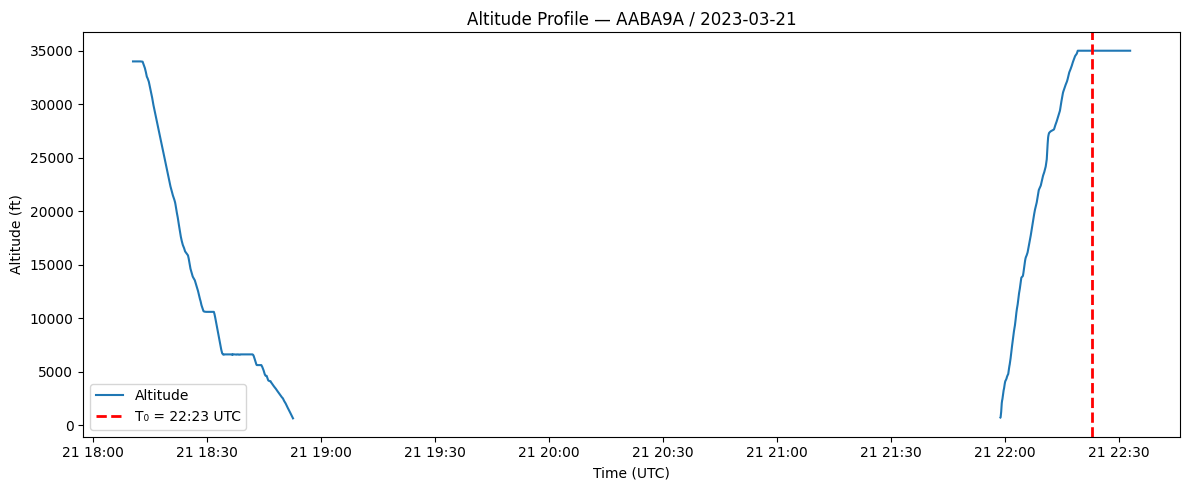

In [225]:
plt.figure(figsize=(12, 5))
plt.plot(traj["timestamp"], traj["altitude"], label="Altitude")

# T0 accident time
t0 = row["timestamp"]
plt.axvline(x=t0, color='red', linestyle='--', linewidth=2, label=f"T₀ = {t0.strftime('%H:%M')} UTC")

plt.xlabel("Time (UTC)")
plt.ylabel("Altitude (ft)")
plt.title(f"Altitude Profile — {row['icao'].upper()} / {t0.strftime('%Y-%m-%d')}")
plt.legend()
plt.tight_layout()
plt.show()

We had the following narrative (description) of the accident:

_United Airlines flight UA194 encountered convective turbulence while climbing through 19,000 ft after departure from San Francisco International Airport (SFO), San Francisco, CA, and a flight attendant was seriously injured. Upon being notified of the injury, the flight crew declared an emergency and diverted to Denver, Colorado for medical assistance. The flight crew reported that before departure, the purser (lead flight attendant) was asked to have the flight attendants remain seated until the 10,000 ft signal due to weather conditions at the departure airport. After departure, airspeed fluctuations and turbulence were encountered with a smooth ride once the airplane was above a cloud layer. About 12,000 ft the captain gave the 10,000 ft signal that it was safe for the flight attendants to begin the initial service. When the flight was about 32 miles northeast of SFO the flight crew established communication with Oakland Air Route Traffic Control Center (ARTCC) while climbing through flight level (FL) 175 [17,500 ft]. The controller advised them to expect occasional light turbulence up to FL 260 and instructed them to climb to FL350. Shortly thereafter, as the airplane climbed through 19,000 ft, the flight encountered unexpected turbulence for about 5 seconds. The flight crew then received a call from the cabin advising them that a flight attendant had fractured her leg. At the time of the turbulence event, one of the flight attendants was in the aft galley preparing her cart for the initial service when she felt âviolent up and down jolting turbulence'. She attempted to move towards the nearest jump seat when another âintense bump' occurred. She was thrown into the air and impacted the floor fracturing her leg. Airmen's Meteorological Information (AIRMETs) were in effect at the time of the accident for moderate turbulence below 12,000 ft and moderate turbulence from FL220 to FL360. A convective Significant Meteorological Information (SIGMET) was issued at 1455 PDT and in effect at the time of the accident for the area with areas of thunderstorms forecast with tops to FL290. A convective SIGMET implies severe or greater turbulence, severe icing, and low-level windshear. Numerous pilot reports (PIREPs) reporting moderate or greater turbulence were issued for central California (including the accident area) within two hours of the accident time. Probable Cause: An encounter with forecast convective turbulence during climb._

The altitude profile shows a textbook climb from SFO: takeoff around 22:00 UTC, 
continuous climb to FL350 by ~22:20 UTC, followed by cruise.

The reported accident time (T₀ = 22:23 UTC) sits in the cruise phase at FL350, 
however the narrative states the turbulence occurred **while climbing through 19,000 ft**, 
which corresponds to approximately **22:10–22:12 UTC** in the trajectory — roughly 
10–13 minutes before the ASN-reported time.

This is a known limitation: ASN timestamps often reflect the **time the emergency was 
declared or reported**, not the exact moment of the incident. In this case the crew 
likely called the emergency after assessing the injured flight attendant, introducing 
a delay of ~10 min relative to the actual event.

**Conclusion:** The ADS-B trajectory is consistent with the narrative. The relevant 
portion of the trajectory is the climb phase between 22:00–22:15 UTC. The aircraft 
continued to FL350 and did not crash — this is an **injury incident**, not a hull loss, 
so the transponder kept transmitting normally through and beyond T₀.

In [226]:
print(f"icao      : {row['icao']}")
print(f"t0        : {t0}")
print(f"n_points  : {len(traj)}")
print(f"first ts  : {traj['timestamp'].min()}")
print(f"last ts   : {traj['timestamp'].max()}")
print(f"last→t0   : {(t0 - traj['timestamp'].max()).total_seconds()/60:.1f} min")
print(f"\nLast 5 points (should be near crash):")
print(traj.tail()[['timestamp','lat','lon','altitude','ground_speed']])
print(f"\nAltitude range: {traj['altitude'].min()} - {traj['altitude'].max()}")
print(f"Speed range   : {traj['ground_speed'].min()} - {traj['ground_speed'].max()}")

icao      : aaba9a
t0        : 2023-03-21 22:23:00+00:00
n_points  : 624
first ts  : 2023-03-21 18:10:26.620000+00:00
last ts   : 2023-03-21 22:32:58.110000+00:00
last→t0   : -10.0 min

Last 5 points (should be near crash):
                           timestamp        lat         lon  altitude  \
619 2023-03-21 22:32:41.540000+00:00  40.314098 -118.939424   35000.0   
620 2023-03-21 22:32:45.430000+00:00  40.318863 -118.948669   35000.0   
621 2023-03-21 22:32:48.590000+00:00  40.322338 -118.956278   35000.0   
622 2023-03-21 22:32:52.810000+00:00  40.326435 -118.966266   35000.0   
623 2023-03-21 22:32:58.110000+00:00  40.330997 -118.979499   35000.0   

     ground_speed  
619         464.9  
620         461.3  
621         458.1  
622         456.2  
623         454.1  

Altitude range: 650.0 - 35000.0
Speed range   : 0.0 - 511.3


Here again we cann se that our time window is working

##### We will now filter out our accident database from DuckDB

UTC Check for both datasets

In [227]:
print(f"Timezone info: {asn_accidents_filtered['timestamp'].dt.tz}")
print(f"Min t0: {asn_accidents_filtered['timestamp'].min()}")
print(f"Max t0: {asn_accidents_filtered['timestamp'].max()}")

Timezone info: UTC
Min t0: 2023-03-21 19:53:00+00:00
Max t0: 2026-05-09 05:15:00+00:00


In [228]:
# Check timezone in DuckDB
print(con.execute("SELECT MIN(CAST(trace.timestamp AS TIMESTAMPTZ)), MAX(CAST(trace.timestamp AS TIMESTAMPTZ)) FROM parquet_scan('{}')".format(CRASH_PATH)).df())

  min(CAST(trace."timestamp" AS "TIMESTAMP WITH TIME ZONE"))  \
0                   2023-03-20 00:00:18.290000+00:00           

  max(CAST(trace."timestamp" AS "TIMESTAMP WITH TIME ZONE"))  
0                   2026-05-09 13:42:49.640000+00:00          


In [229]:
results = []

for _, row in asn_accidents_filtered.iterrows():
    if pd.isna(row['timestamp']):
        continue
    traj = fetch_trajectory(row['icao'], row['timestamp'])
    results.append(traj)

trajectories = pd.concat(results, ignore_index=True)

In [230]:
flight_lens = trajectories.groupby("icao").size()
print(f"Flights with < 10 points: {(flight_lens < 10).sum()}")


Flights with < 10 points: 1


In [231]:
trajectories.head()

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,geometric_vertical_rate,indicated_airspeed,roll_angle,flags,source,h3_5,aircraft
0,aaba9a,B772,0,2023-03-21 18:10:26.620000+00:00,37.431885,-125.534811,34000.0,32900.0,506.2,94.0,0.0,NaN,<NA>,NaN,1,adsb_icao,8528200bfffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
1,aaba9a,B772,0,2023-03-21 18:10:55.600000+00:00,37.427254,-125.450015,34000.0,32900.0,508.1,93.8,0.0,NaN,<NA>,NaN,0,adsb_icao,8528200bfffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
2,aaba9a,B772,0,2023-03-21 18:11:24.840000+00:00,37.422553,-125.364095,34000.0,32900.0,508.2,93.9,0.0,NaN,<NA>,NaN,0,adsb_icao,85282057fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."
3,aaba9a,B772,0,2023-03-21 18:11:54.550000+00:00,37.417665,-125.276443,34000.0,32900.0,509.3,94.1,0.0,NaN,<NA>,NaN,0,adsb_icao,85282043fffffff,"{'alert': 0, 'alt_geom': 32900.0, 'baro_rate':..."
4,aaba9a,B772,0,2023-03-21 18:12:24.490000+00:00,37.412684,-125.188134,34000.0,32900.0,511.3,94.0,0.0,NaN,<NA>,NaN,0,adsb_icao,85282043fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':..."


##### Flight Identification

**Goal:** Assign a unique `flight_id` per continuous flight trajectory per ICAO.
We split flights using a 30-min time gap threshold, but only when the aircraft 
was near the ground (altitude < 500ft) at the split point, ensuring mid-cruise 
ADS-B dropouts are not mistakenly treated as separate flights.

**Note:** 500ft (~150m) was chosen as the altitude cutoff as it corresponds to 
final approach phase (https://skybrary.aero/tutorials/descent-approach-and-landing), where no commercial jet is in cruise or climb. 

In [232]:
print(f"Unique aircraft: {trajectories['icao'].nunique()}")

Unique aircraft: 175


In [233]:
trajectories = trajectories.sort_values(['icao', 'timestamp']).reset_index(drop=True)

In [234]:
gaps = trajectories.sort_values(['icao', 'timestamp']).groupby('icao')['timestamp'].diff()
print(gaps.describe())
print(f"\nGaps > 15min: {(gaps > pd.Timedelta(minutes=15)).sum()}")
print(f"Gaps > 30min: {(gaps > pd.Timedelta(minutes=30)).sum()}")
print(f"Gaps > 1h: {(gaps > pd.Timedelta(hours=1)).sum()}")
print(f"Gaps > 2h: {(gaps > pd.Timedelta(hours=2)).sum()}")
print(f"Gaps > 3h: {(gaps > pd.Timedelta(hours=3)).sum()}")
print(f"Gaps > 4h: {(gaps > pd.Timedelta(hours=4)).sum()}")

count                    131146
mean     0 days 00:00:19.065813
std      0 days 00:17:30.510159
min             0 days 00:00:00
25%      0 days 00:00:02.710000
50%      0 days 00:00:06.420000
75%      0 days 00:00:18.020000
max      4 days 07:37:17.590000
Name: timestamp, dtype: object

Gaps > 15min: 171
Gaps > 30min: 141
Gaps > 1h: 103
Gaps > 2h: 35
Gaps > 3h: 11
Gaps > 4h: 3


In [235]:
trajectories2 = trajectories.copy()

time_diff   = trajectories2.groupby('icao')['timestamp'].diff()
time_gap    = time_diff > pd.Timedelta(minutes=20)
long_gap    = time_diff > pd.Timedelta(hours=3)
near_ground = (trajectories2['altitude'].abs() < 3000) | (trajectories2['ground_speed'].abs() < 50)
is_first    = time_diff.isna() 

new_flight  = (time_gap & near_ground) | long_gap | is_first

trajectories2['flight_id_num'] = new_flight.astype(int).groupby(trajectories2['icao']).cumsum()
trajectories2['flight_id'] = trajectories2['icao'] + '_' + trajectories2['flight_id_num'].astype(str)

total_flights = trajectories2['flight_id'].nunique()

last_flights = trajectories2.groupby('icao')['flight_id_num'].max()
trajectories2 = trajectories2[trajectories2['flight_id_num'] == trajectories2['icao'].map(last_flights)]

trajectories2 = trajectories2.drop(columns=['flight_id_num'])

kept_flights = trajectories2['flight_id'].nunique()
print(f"Total ICAOs: {trajectories['icao'].nunique()}")
print(f"Total flights identified: {total_flights}")
print(f"Flights kept (last per ICAO): {kept_flights}")
print(f"Flights cut: {total_flights - kept_flights}")

Total ICAOs: 175
Total flights identified: 276
Flights kept (last per ICAO): 175
Flights cut: 101


In [236]:
gaps = trajectories2.sort_values(['icao', 'timestamp']).groupby('icao')['timestamp'].diff()
print(gaps.describe())
print(f"\nGaps > 15min: {(gaps > pd.Timedelta(minutes=15)).sum()}")
print(f"Gaps > 30min: {(gaps > pd.Timedelta(minutes=30)).sum()}")
print(f"Gaps > 1h: {(gaps > pd.Timedelta(hours=1)).sum()}")
print(f"Gaps > 6h: {(gaps > pd.Timedelta(hours=6)).sum()}")

count                     84653
mean     0 days 00:00:12.380097
std      0 days 00:01:36.141094
min             0 days 00:00:00
25%      0 days 00:00:02.620000
50%      0 days 00:00:06.710000
75%      0 days 00:00:19.220000
max      0 days 02:54:23.600000
Name: timestamp, dtype: object

Gaps > 15min: 54
Gaps > 30min: 31
Gaps > 1h: 19
Gaps > 6h: 0


In [237]:
top_icaos = (
    trajectories2.sort_values(['icao', 'timestamp'])
    .groupby('flight_id')['timestamp']
    .diff()
    .groupby(trajectories2['flight_id'])
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)


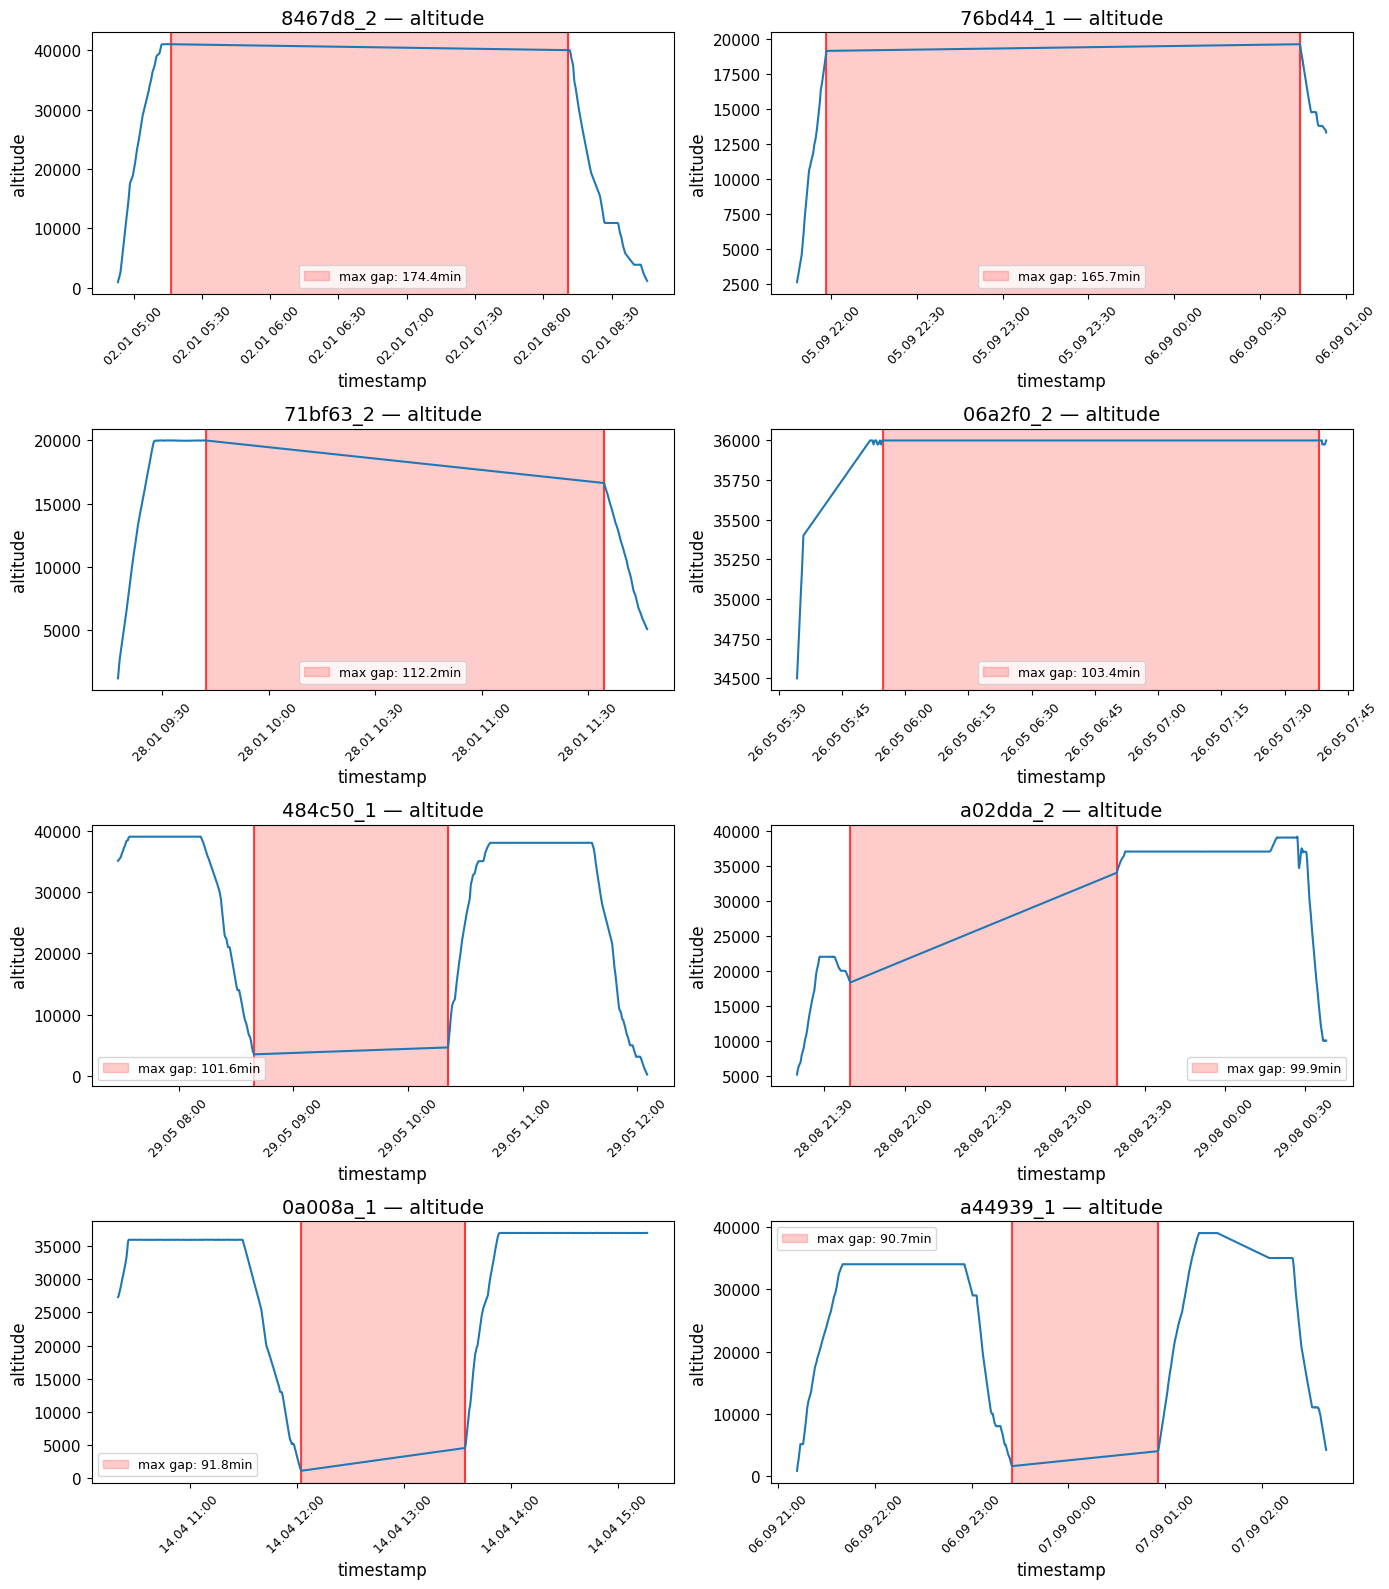

In [238]:
from src.traces.plots_traces import *
plot_top_flights_pd(trajectories2, top_icaos, "altitude", "timestamp", n=8)

In [239]:
durations = (
    trajectories2.groupby('flight_id')['timestamp']
    .agg(lambda x: x.max() - x.min())
)

print(durations.describe())
print(f"\nDuration > 1h:   {(durations > pd.Timedelta(hours=1)).sum()}")
print(f"Duration > 6h:   {(durations > pd.Timedelta(hours=6)).sum()}")
print(f"Duration > 12h:  {(durations > pd.Timedelta(hours=12)).sum()}")
print(f"Duration > 18h:  {(durations > pd.Timedelta(hours=18)).sum()}")
print(f"Duration > 24h:  {(durations > pd.Timedelta(hours=24)).sum()}")

count                       175
mean     0 days 01:39:48.642057
std      0 days 01:24:11.367558
min             0 days 00:00:00
25%      0 days 00:34:15.045000
50%      0 days 01:16:13.550000
75%      0 days 02:20:09.925000
max      0 days 05:39:51.920000
Name: timestamp, dtype: object

Duration > 1h:   100
Duration > 6h:   0
Duration > 12h:  0
Duration > 18h:  0
Duration > 24h:  0


In [240]:
last_flights = trajectories2.groupby('icao')['flight_id'].last()
accident_trajectories = trajectories2[trajectories2['flight_id'].isin(last_flights)].copy()

print(f"Flights remaining: {accident_trajectories['flight_id'].nunique()}")

Flights remaining: 175


In [241]:
asn_accidents_filtered['icao'] = asn_accidents_filtered['icao'].str.lower()
t0_lookup = asn_accidents_filtered.set_index('icao')['timestamp'].to_dict()
accident_trajectories['t0'] = accident_trajectories['icao'].map(t0_lookup)

In [242]:
print(f"Missing t0: {accident_trajectories['t0'].isna().sum()}")

Missing t0: 0


In [243]:
accident_trajectories.head()

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,geometric_vertical_rate,indicated_airspeed,roll_angle,flags,source,h3_5,aircraft,flight_id,t0
0,00a61a,B190,0,2023-11-01 07:39:08.950000+00:00,-26.593781,27.656371,21950.0,23375.0,209.4,208.5,64.0,64.0,<NA>,NaN,4,adsb_icao,85bcc38ffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",00a61a_1,2023-11-01 13:09:00+00:00
1,00a61a,B190,0,2023-11-01 07:39:28.380000+00:00,-26.610535,27.646110,21925.0,23350.0,214.0,209.1,0.0,0.0,<NA>,NaN,4,adsb_icao,85bcc383fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",00a61a_1,2023-11-01 13:09:00+00:00
2,00a61a,B190,0,2023-11-01 07:39:48.280000+00:00,-26.627701,27.635227,21950.0,23375.0,215.9,210.0,-64.0,-64.0,<NA>,NaN,4,adsb_icao,85bcc383fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",00a61a_1,2023-11-01 13:09:00+00:00
3,00a61a,B190,0,2023-11-01 07:40:06.510000+00:00,-26.643814,27.625018,21950.0,23375.0,218.6,209.6,192.0,192.0,<NA>,NaN,4,adsb_icao,85bcc383fffffff,"{'alert': 0, 'alt_geom': 23375.0, 'baro_rate':...",00a61a_1,2023-11-01 13:09:00+00:00
4,00a61a,B190,0,2023-11-01 07:40:26.440000+00:00,-26.661398,27.613977,22000.0,23425.0,218.6,209.6,-64.0,-64.0,<NA>,NaN,4,adsb_icao,85bcc383fffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",00a61a_1,2023-11-01 13:09:00+00:00


In [244]:
accident_trajectories.info()

<class 'pandas.DataFrame'>
Index: 84828 entries, 0 to 131320
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   icao                     84828 non-null  object             
 1   type                     84828 non-null  object             
 2   dbFlags                  84828 non-null  int64              
 3   timestamp                84828 non-null  datetime64[us, UTC]
 4   lat                      84828 non-null  float64            
 5   lon                      84828 non-null  float64            
 6   altitude                 77058 non-null  float64            
 7   altitude_geom            76229 non-null  float64            
 8   ground_speed             83770 non-null  float64            
 9   track_degrees            82759 non-null  float64            
 10  vertical_rate            77138 non-null  float64            
 11  geometric_vertical_rate  36268 non-null  fl

We have 175 accidents flights with our desired time windows. In total we have around 85 thousand trace points.

#### Removing Duplicate values

In [245]:
total = len(accident_trajectories)
dupes = accident_trajectories.duplicated(subset=["icao", "timestamp"], keep=False).sum()
print(f"Duplicate rows: {dupes} ({dupes/total*100:.3f}%)")

Duplicate rows: 34 (0.040%)


In [246]:
dupes_df = accident_trajectories[accident_trajectories.duplicated(subset=["icao", "timestamp"], keep=False)]
print(dupes_df[["icao", "timestamp", "source", "altitude", "ground_speed", "vertical_rate"]].sort_values(["icao", "timestamp"]))

          icao                        timestamp     source  altitude  \
27752   4cae58 2026-03-29 07:12:33.400000+00:00  adsb_icao       NaN   
27753   4cae58 2026-03-29 07:12:33.400000+00:00  adsb_icao    -100.0   
27754   4cae58 2026-03-29 07:12:33.400000+00:00  adsb_icao       NaN   
41364   84c586 2025-12-07 22:46:52.960000+00:00       mlat    7150.0   
41365   84c586 2025-12-07 22:46:52.960000+00:00       mlat    7150.0   
41366   84c586 2025-12-07 22:46:52.960000+00:00       mlat    7150.0   
50221   a12710 2025-10-16 12:05:19.120000+00:00  adsb_icao    5525.0   
50222   a12710 2025-10-16 12:05:19.120000+00:00  adsb_icao       NaN   
63623   a33741 2025-07-26 20:20:13.820000+00:00  tisb_icao       NaN   
63624   a33741 2025-07-26 20:20:13.820000+00:00  tisb_icao       NaN   
63628   a33741 2025-07-26 20:20:24.830000+00:00  tisb_icao       NaN   
63629   a33741 2025-07-26 20:20:24.830000+00:00  tisb_icao       NaN   
63630   a33741 2025-07-26 20:20:26.800000+00:00  tisb_icao      

In [247]:
accident_trajectories = accident_trajectories.drop_duplicates(subset=["icao", "timestamp"], keep="first")
print(f"Rows remaining: {len(accident_trajectories)}")

Rows remaining: 84810


In [248]:
accident_trajectories['flight_id'].nunique()

175

#### Cleansing NaN Values

In [249]:
check_nan(accident_trajectories)

⚠️ NaN summary:
                         NaN_count NaN_percent
icao                             0       0.0 %
type                             0       0.0 %
dbFlags                          0       0.0 %
timestamp                        0       0.0 %
lat                              0       0.0 %
lon                              0       0.0 %
altitude                      7755      9.14 %
altitude_geom                 8582     10.12 %
ground_speed                  1058      1.25 %
track_degrees                 2056      2.42 %
vertical_rate                 7675      9.05 %
geometric_vertical_rate      48542     57.24 %
indicated_airspeed           54537      64.3 %
roll_angle                   56170     66.23 %
flags                            0       0.0 %
source                           0       0.0 %
h3_5                             0       0.0 %
aircraft                         0       0.0 %
flight_id                        0       0.0 %
t0                               0       0.0

We drop all columns with more than 50% NaN values: `geometric_vertical_rate`, 
`indicated_airspeed`, and `roll_angle`. At this level of missingness, 
these columns are not viable as ML features. For `geometric_vertical_rate` 
specifically, `vertical_rate` serves as a reliable substitute.

In [250]:
df_traj = drop_high_nan_columns(accident_trajectories)

Dropping 3 columns with more than 30% NaN values.
Dropped columns: ['geometric_vertical_rate', 'indicated_airspeed', 'roll_angle']


In [251]:
df_traj = df_traj.sort_values(['icao', 'timestamp']).reset_index(drop=True)

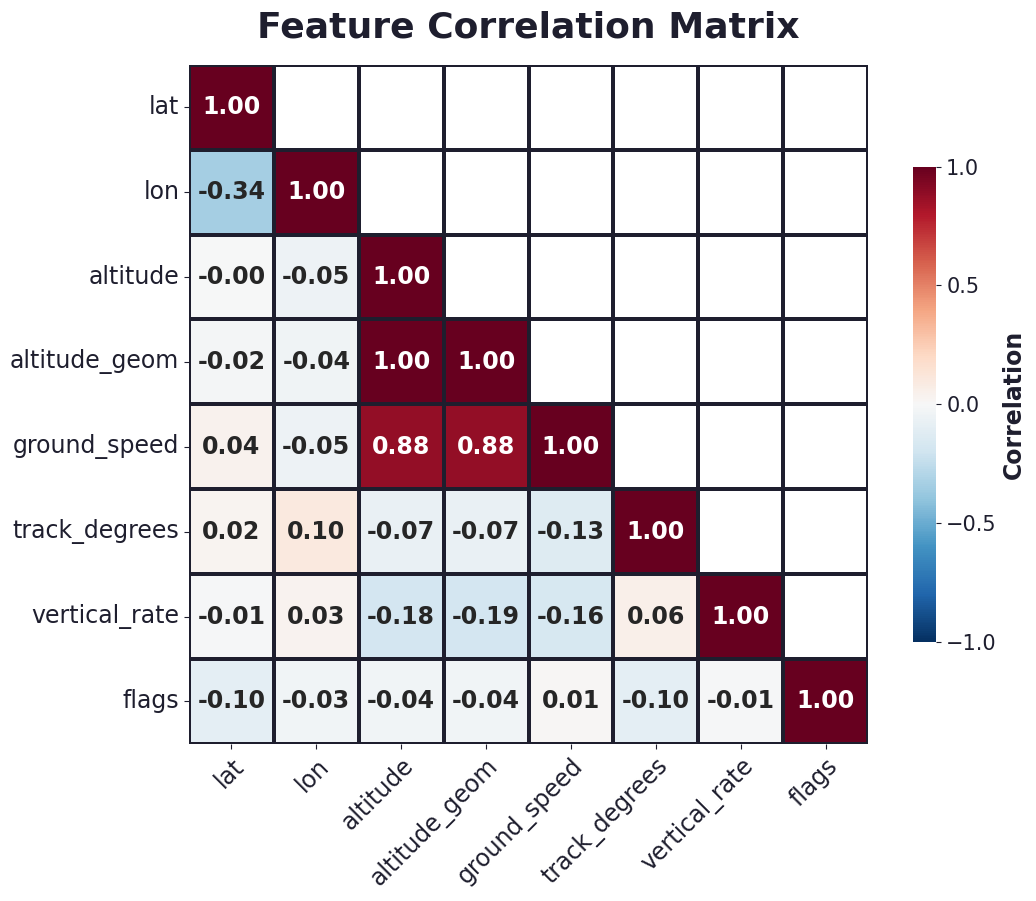

In [252]:
from src.common.plots import *
save_path = IMAGE_DIR / "corr_acc.png"
plot_corr(df_traj.drop("dbFlags", axis=1), transparent=True, save_path=save_path, dark=False)

The matrix highlights two strong correlations: altitude ↔ altitude_geom (~1.00) and both ↔ ground_speed (~0.88), inspiring our imputation strategy, the two altitude columns serve as natural fallbacks for each other, and ground_speed is a reliable ground-state proxy.

##### Ground Speed NaNs

We will start with the cleansing of ground speed, as this column will be used quite a bit when cleansing other columns

In [253]:
nan_gs = df_traj[df_traj['ground_speed'].isna()]

In [254]:
print(nan_gs["altitude"].describe())

count     1058.000000
mean     16266.965974
std       9751.306487
min        -50.000000
25%      11375.000000
50%      12375.000000
75%      15300.000000
max      40000.000000
Name: altitude, dtype: float64


In [255]:
top_icaos = nan_gs["icao"].value_counts().head(10)
top_icaos

icao
70a9f6    702
e49b02     43
4ca9aa     19
ab6909     16
40665f     12
a8de7d     11
a86ab5     10
4aca15      9
3c6470      8
a43b77      8
Name: count, dtype: int64

In [256]:
print(nan_gs["icao"].value_counts().info())

<class 'pandas.Series'>
Index: 87 entries, 70a9f6 to e495a7
Series name: count
Non-Null Count  Dtype
--------------  -----
87 non-null     int64
dtypes: int64(1)
memory usage: 1.4+ KB
None


We have 87 ICAOs with missing NaNs in ground speed

In [257]:
all_nan_track = df_traj.groupby("icao")["ground_speed"].apply(lambda x: x.isna().all())
print(f"ICАOs with no ground_speed values at all: {all_nan_track[all_nan_track].index.tolist()}")
print(f"Count: {all_nan_track.sum()}")

ICАOs with no ground_speed values at all: ['e49b02']
Count: 1


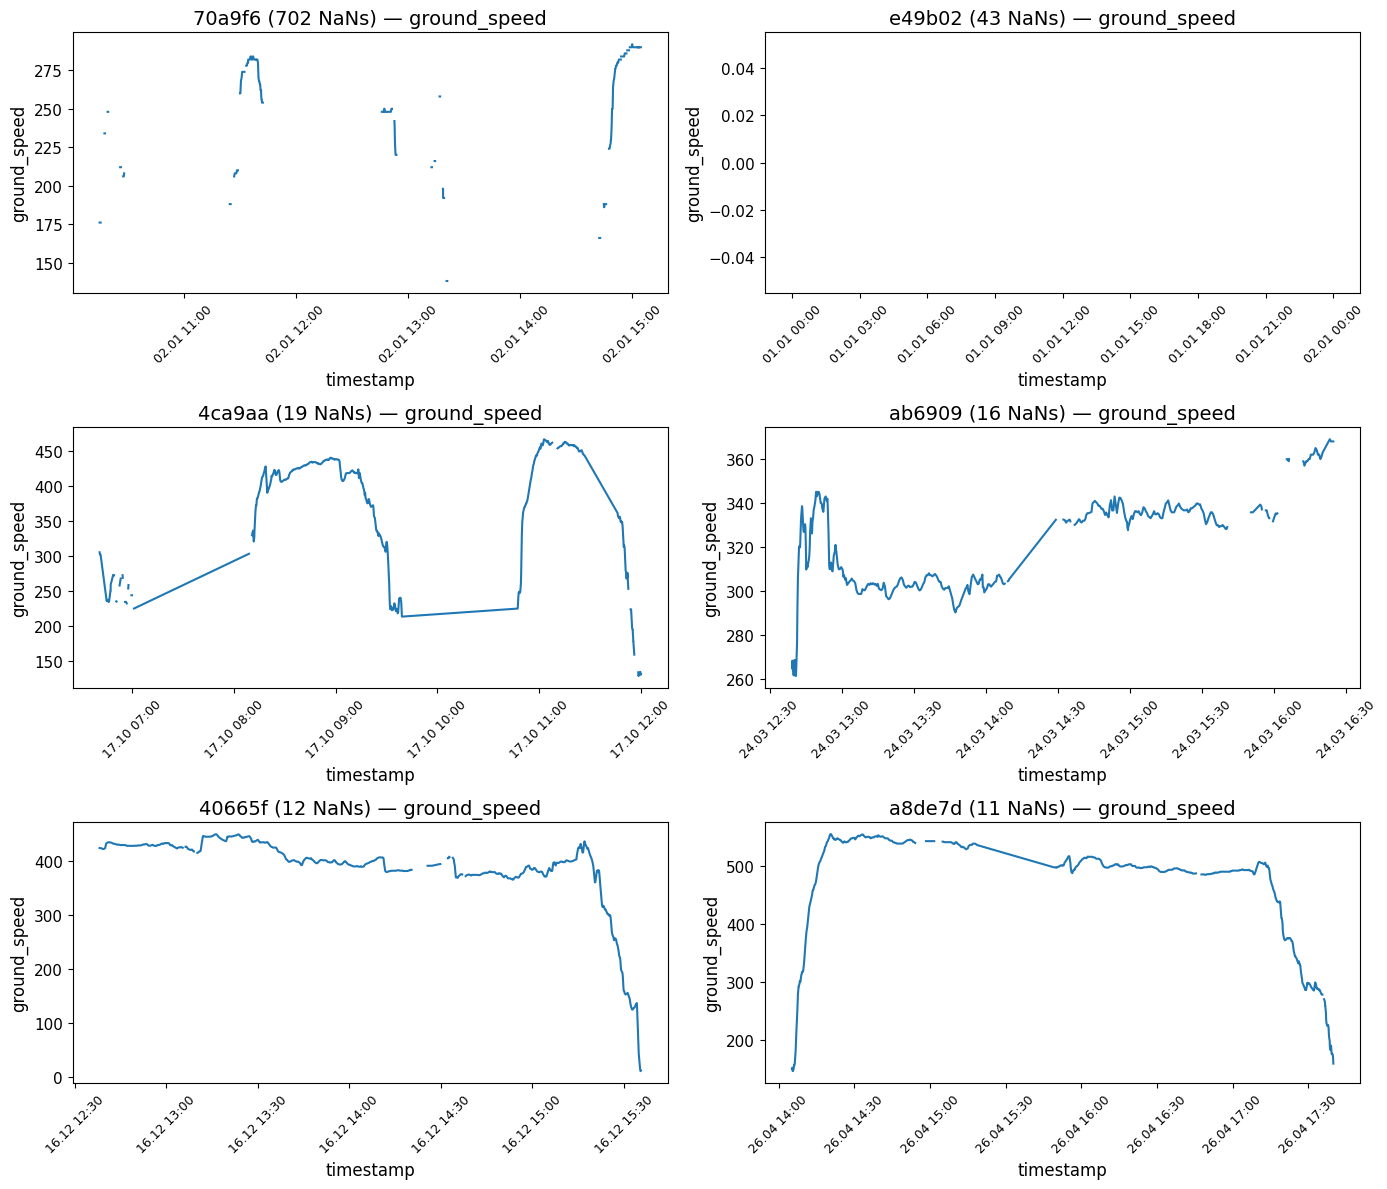

In [258]:
plot_top_icao(df_traj, top_icaos, "ground_speed", "timestamp", n=6)

The plots reveal small to moderate gaps in otherwise continuous speed profiles. While some aircraft show larger discontinuities, these affect only ~0.5% of the total dataset, too negligible to justify complex imputation. We proceed with linear interpolation per aircraft trajectory. The exception is e49b02, which has no ground speed data at all, however, as this represents a critical crash event, we retain it and impute its ground speed with the global median to avoid losing this valuable sample.

In [259]:
df_traj["ground_speed"] = df_traj.groupby("icao")["ground_speed"].transform(
    lambda x: x.interpolate(method="linear")
)
df_traj['ground_speed'] = df_traj.groupby('icao')['ground_speed'].transform('ffill') 
df_traj['ground_speed'] = df_traj.groupby('icao')['ground_speed'].transform('bfill') 


In [260]:
print(df_traj["ground_speed"].isna().sum()/len(df_traj))

0.0005070156821129583


In [261]:
global_median_gs = df_traj["ground_speed"].median()

df_traj.loc[df_traj["icao"] == "e49b02", "ground_speed"] = df_traj.loc[
    df_traj["icao"] == "e49b02", "ground_speed"
].fillna(global_median_gs)

In [262]:
print(df_traj["ground_speed"].isna().sum()/len(df_traj))

0.0


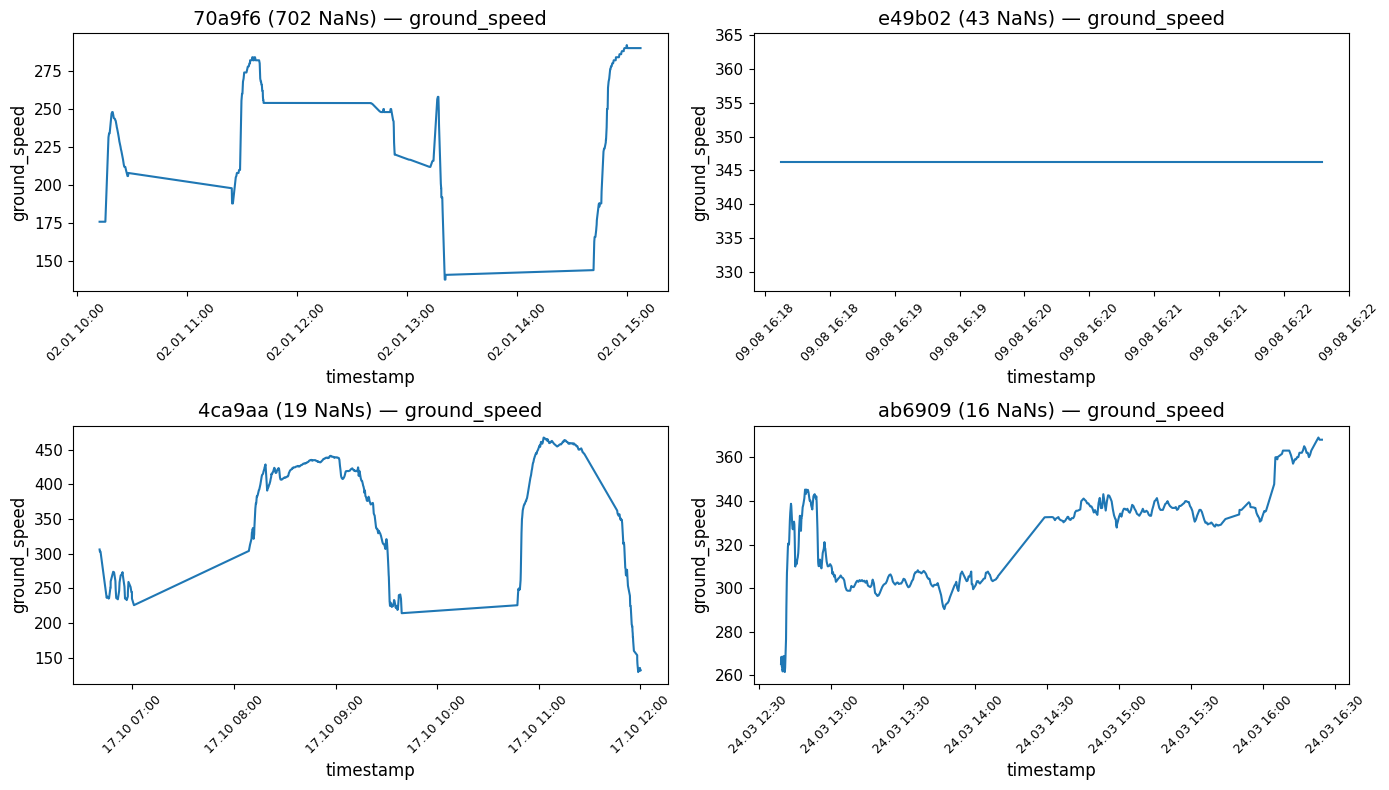

In [263]:
plot_top_icao(df_traj, top_icaos, "ground_speed", "timestamp", n=4)

##### "altitude" and "altitude_geom" NaNs

We observed that `altitude` and `altitude_geom` contain ~10% NaN values. 
These are critical columns, so careful imputation is needed.

**Hypothesis:** Most NaN values correspond to ground operations (gate, taxi, 
holding). Transponders often do not broadcast barometric altitude while on the 
surface, so these NaNs reflect expected sensor behavior rather than data loss.

**Verification:** We compute the share of NaN-altitude rows with 
`ground_speed < 30 kt`. If the vast majority falls in this regime, the 
hypothesis holds and we impute these values with `0 ft`.

**Threshold rationale:** Industry practice (Boeing FCTM, common airline SOPs) 
caps taxi speed at ~25 kt on straight taxiways and ~30 kt on long taxi routes. 
Since takeoff rotation occurs around 130–160 kt, the 30 kt threshold leaves a 
wide margin and cannot be confused with active flight phases.

**Remaining NaNs** (in-flight, ground_speed ≥ 30 kt) are treated as data 
quality issues and handled in a second step.

> **Note:** ICAO guidelines recommend a maximum taxi speed of 25 kts on straight 
> taxiways (https://www.aviationfile.com/taxiing-by-the-numbers-maintaining-safe-speeds-on-the-apron/), while 30 kts is accepatable on long routes (https://aviationtricks.com/wp-content/uploads/2025/03/B737_FCTM-1.pdf)
> as our threshold to ensure we capture all ground operations without accidentally 
> including actual flight phases.

We define "altitude" and "altitude_geom" as fallback columns to each other, as these are very similar to each other, only differing in their measurement method and also ahd a correlation of 1. "Altitude" being barometrically measured by the aircraft itself, while "altitude_geom" refers to the geometric/GPS-derived altitude. When one is unavailable, the other serves as a reasonable substitute.

In [264]:
df_traj[["altitude", "altitude_geom"]]

,altitude,altitude_geom
0,21950.0,23375.0
1,21925.0,23350.0
2,21950.0,23375.0
3,21950.0,23375.0
4,22000.0,23425.0
...,...,...
84805,7225.0,NaN
84806,6875.0,NaN
84807,6675.0,NaN
84808,5975.0,NaN


In [265]:
in_air_nan = df_traj[df_traj["altitude"].isna()]
print(f"altitude_geom available as fallback: {in_air_nan['altitude_geom'].notna().sum()} / {len(in_air_nan)}")

altitude_geom available as fallback: 490 / 7755


In [266]:
in_air_nan2 = df_traj[df_traj["altitude_geom"].isna()]
print(f"altitude available as fallback: {in_air_nan2['altitude'].notna().sum()} / {len(in_air_nan2)}")

altitude available as fallback: 1317 / 8582


In [267]:
df_traj['altitude'] = df_traj['altitude'].fillna(
    df_traj['altitude_geom']
)

In [268]:
df_traj['altitude_geom'] = df_traj['altitude_geom'].fillna(
    df_traj['altitude']
)

In [269]:
no_icaos  = df_traj.groupby("icao")["altitude"].apply(lambda x: x.isna().all())
print(f"ICАOs with no altitude values at all: {no_icaos [no_icaos].index.tolist()}")
print(f"Count: {no_icaos.sum()}")

ICАOs with no altitude values at all: ['407699', '44ce66', '4d2332', 'a1cf6b', 'a32814', 'a44240', 'a449a1', 'a79898', 'a87c12', 'aac337', 'ac78b0', 'ad4bcb', 'c04463', 'c080ac']
Count: 14


In [270]:
no_icaos2  = df_traj.groupby("icao")["altitude_geom"].apply(lambda x: x.isna().all())
print(f"ICАOs with no altitude_geom values at all: {no_icaos2[no_icaos2].index.tolist()}")
print(f"Count: {no_icaos2.sum()}")

ICАOs with no altitude_geom values at all: ['407699', '44ce66', '4d2332', 'a1cf6b', 'a32814', 'a44240', 'a449a1', 'a79898', 'a87c12', 'aac337', 'ac78b0', 'ad4bcb', 'c04463', 'c080ac']
Count: 14


We will delete these ICAOs withou altitude we can not detect any flight phase

In [271]:
df_traj['flight_id'].nunique()

175

In [272]:
icaos_no_alt = no_icaos[no_icaos].index.tolist()
df_traj = df_traj[~df_traj["icao"].isin(icaos_no_alt)]

In [273]:
df_traj['flight_id'].nunique()

161

In [274]:
nan_alt = df_traj[df_traj['altitude'].isna()]
nan_alt

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,aircraft,flight_id,t0
4227,3c5427,A306,0,2025-10-12 14:36:55.600000+00:00,51.407904,12.232761,NaN,NaN,2.8,73.1,NaN,1,adsb_icao,851f1a8ffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",3c5427_1,2025-10-12 16:13:00+00:00
4228,3c5427,A306,0,2025-10-12 14:36:59.320000+00:00,51.407904,12.232666,NaN,NaN,2.8,67.5,NaN,0,adsb_icao,851f1a8ffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",3c5427_1,2025-10-12 16:13:00+00:00
4229,3c5427,A306,0,2025-10-12 14:45:00.120000+00:00,51.411232,12.251720,NaN,NaN,23.5,87.2,NaN,1,adsb_icao,851f1a8ffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",3c5427_1,2025-10-12 16:13:00+00:00
4230,3c5427,A306,0,2025-10-12 14:45:01.980000+00:00,51.411244,12.251987,NaN,NaN,23.5,84.4,NaN,0,adsb_icao,851f1a8ffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",3c5427_1,2025-10-12 16:13:00+00:00
4231,3c5427,A306,0,2025-10-12 14:45:10.770000+00:00,51.411312,12.253542,NaN,NaN,23.5,87.2,NaN,0,adsb_icao,851f1a8ffffffff,"{'alert': 0, 'alt_geom': None, 'baro_rate': No...",3c5427_1,2025-10-12 16:13:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84744,c08497,A321,0,2023-07-20 22:28:24.740000+00:00,43.676008,-79.616874,NaN,NaN,20.5,317.8,NaN,0,adsb_icao,852b9bcffffffff,"{'alert': 0, 'alt_geom': None, 'baro_rate': No...",c08497_1,2023-07-21 02:16:00+00:00
84745,c08497,A321,0,2023-07-20 22:28:28.340000+00:00,43.676252,-79.617201,NaN,NaN,20.5,317.8,NaN,0,adsb_icao,852b9bcffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",c08497_1,2023-07-21 02:16:00+00:00
84746,c08497,A321,0,2023-07-20 22:28:31.130000+00:00,43.676462,-79.617462,NaN,NaN,21.5,317.8,NaN,0,adsb_icao,852b9bcffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",c08497_1,2023-07-21 02:16:00+00:00
84747,c08497,A321,0,2023-07-20 22:28:43.470000+00:00,43.677303,-79.618559,NaN,NaN,18.5,317.8,NaN,0,adsb_icao,852b9bcffffffff,"{'alert': None, 'alt_geom': None, 'baro_rate':...",c08497_1,2023-07-21 02:16:00+00:00


In [275]:
thresholds = [10, 15, 30, 50, 75, 100]
for t in thresholds:
    n = (nan_alt['ground_speed'] >= t).sum()
    pct = n / len(nan_alt) * 100
    print(f"ground_speed >= {t} kts: {n} ({pct:.1f}%)")

ground_speed >= 10 kts: 3090 (52.7%)
ground_speed >= 15 kts: 1708 (29.1%)
ground_speed >= 30 kts: 386 (6.6%)
ground_speed >= 50 kts: 269 (4.6%)
ground_speed >= 75 kts: 144 (2.5%)
ground_speed >= 100 kts: 40 (0.7%)


Of the ~6000 NaN altitude rows, around 93% have a ground speed below 30 kts, 
confirming our assumption that the vast majority are ground operations.
The remaining ~8% (~260 rows) above 30 kts will be handled separately.

In [276]:
df_traj.loc[
    (df_traj['altitude'].isna()) & 
    (df_traj['ground_speed'] <= 30), 
    'altitude'
] = 0

In [277]:
df_traj.loc[
    (df_traj['altitude_geom'].isna()) & 
    (df_traj['ground_speed'] <= 30), 
    'altitude_geom'
] = 0

Let's further analyse the remaining NaN altittude values

In [278]:
both_nan = df_traj[df_traj["altitude"].isna() | df_traj["altitude_geom"].isna()]
print(both_nan["ground_speed"].describe())

count    386.000000
mean      68.757772
std       30.268500
min       30.500000
25%       45.500000
50%       65.500000
75%       83.000000
max      167.500000
Name: ground_speed, dtype: float64



The remaining ~400 rows have no altitude fallback available. They cluster in the takeoff/landing roll regime (mean ~65 kt, max 167 kt).

In [279]:
top_icaos = both_nan["icao"].value_counts().head(10)
top_icaos

icao
850d8c    39
a33741    38
a50370    22
a12710    21
4cae58    19
a39723    17
a7811e    15
ac31a1    15
a8d4cc    14
a8f3c5    13
Name: count, dtype: int64

In [280]:
print(both_nan["icao"].value_counts().info())

<class 'pandas.Series'>
Index: 41 entries, 850d8c to aaf665
Series name: count
Non-Null Count  Dtype
--------------  -----
41 non-null     int64
dtypes: int64(1)
memory usage: 656.0+ bytes
None


We have 41 ICAOs with missing NaNs left

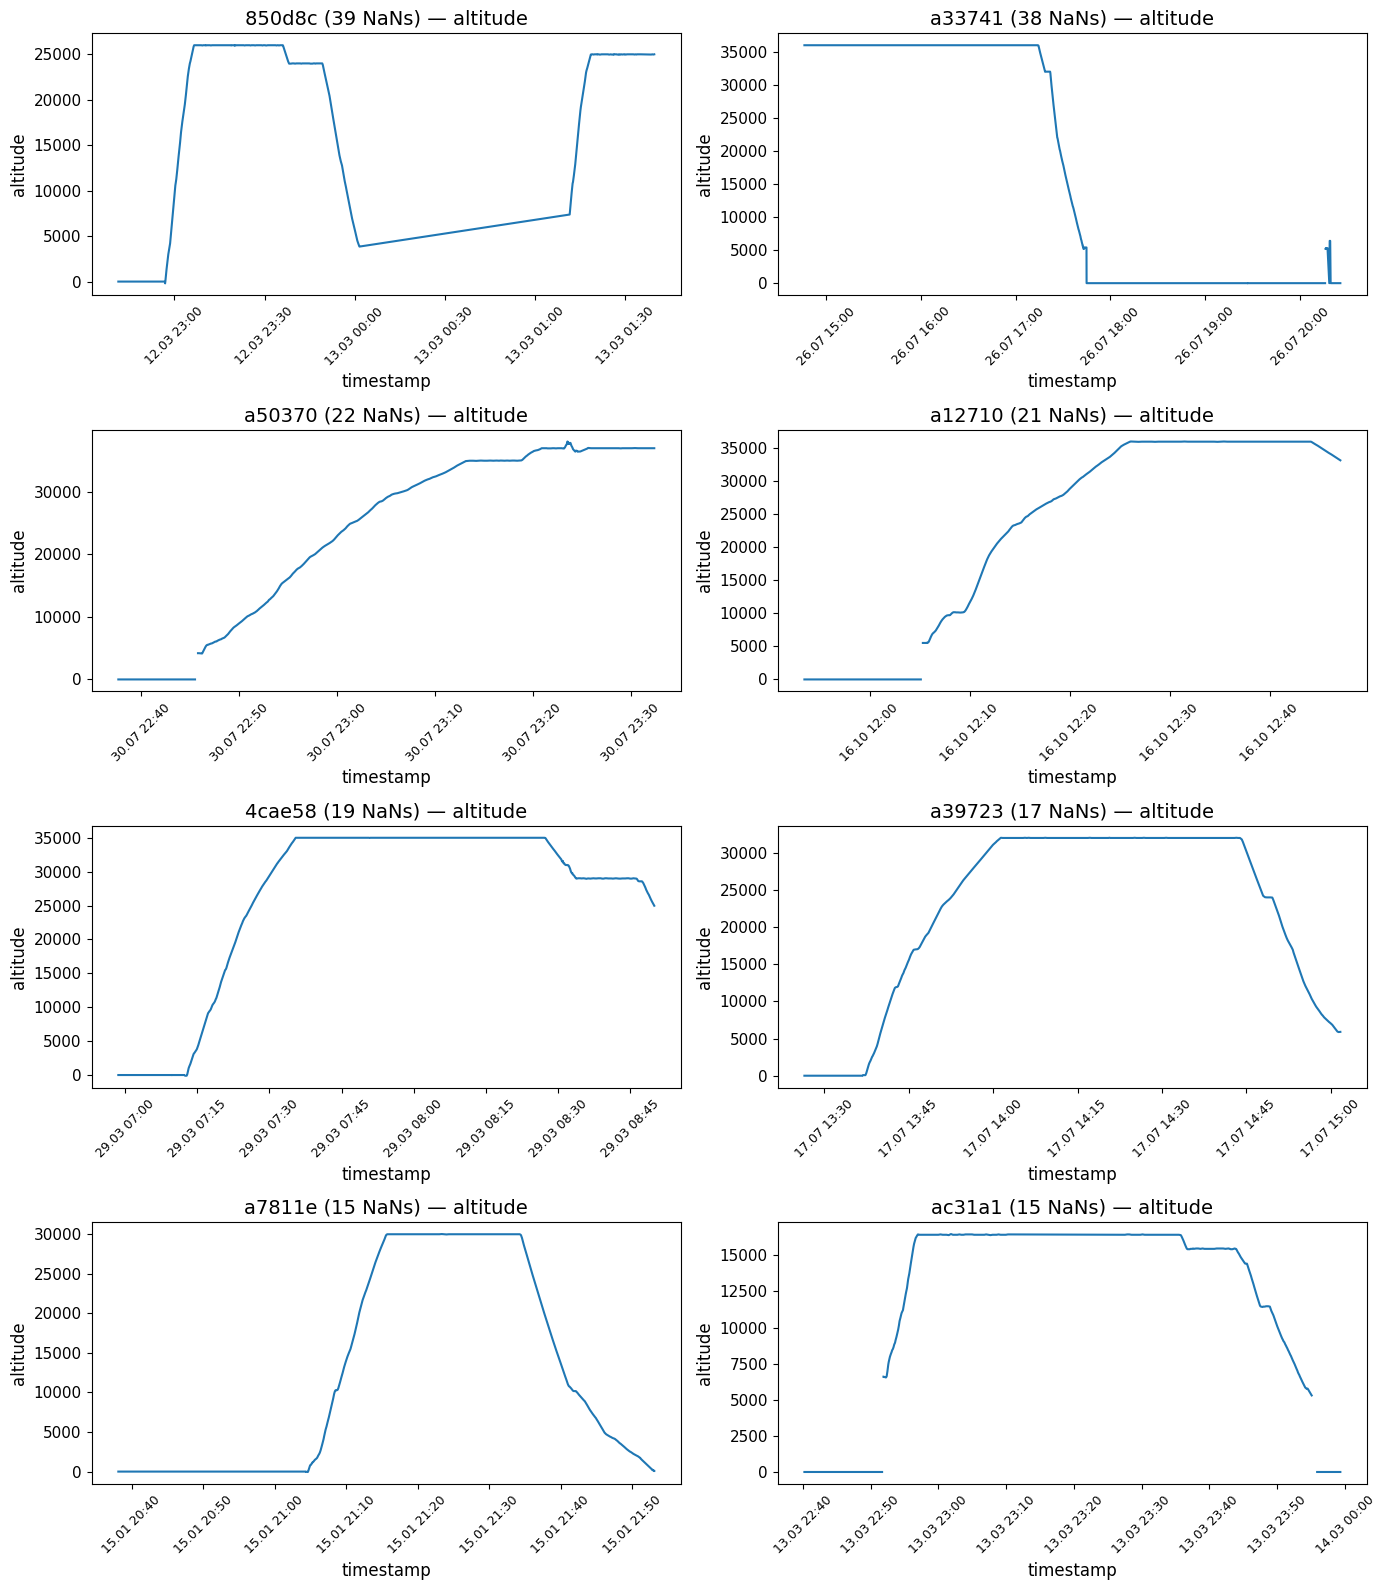

In [281]:
plot_top_icao(df_traj, top_icaos, "altitude", "timestamp")


All 8 plots show NaNs concentrated at the ground ↔ liftoff transition (altitude jumping from 0 to first reported value). Since we have solid anchors on both sides (0 ft and first/last known altitude), linear interpolation is physically reasonable. The aircraft is in a steady initial climb/descent rate across that short gap as we assume.

In [282]:
df_traj["altitude"] = df_traj.groupby("icao")["altitude"].transform(
    lambda x: x.interpolate(method="linear")
)

In [283]:
df_traj["altitude_geom"] = df_traj.groupby("icao")["altitude_geom"].transform(
    lambda x: x.interpolate(method="linear")
)

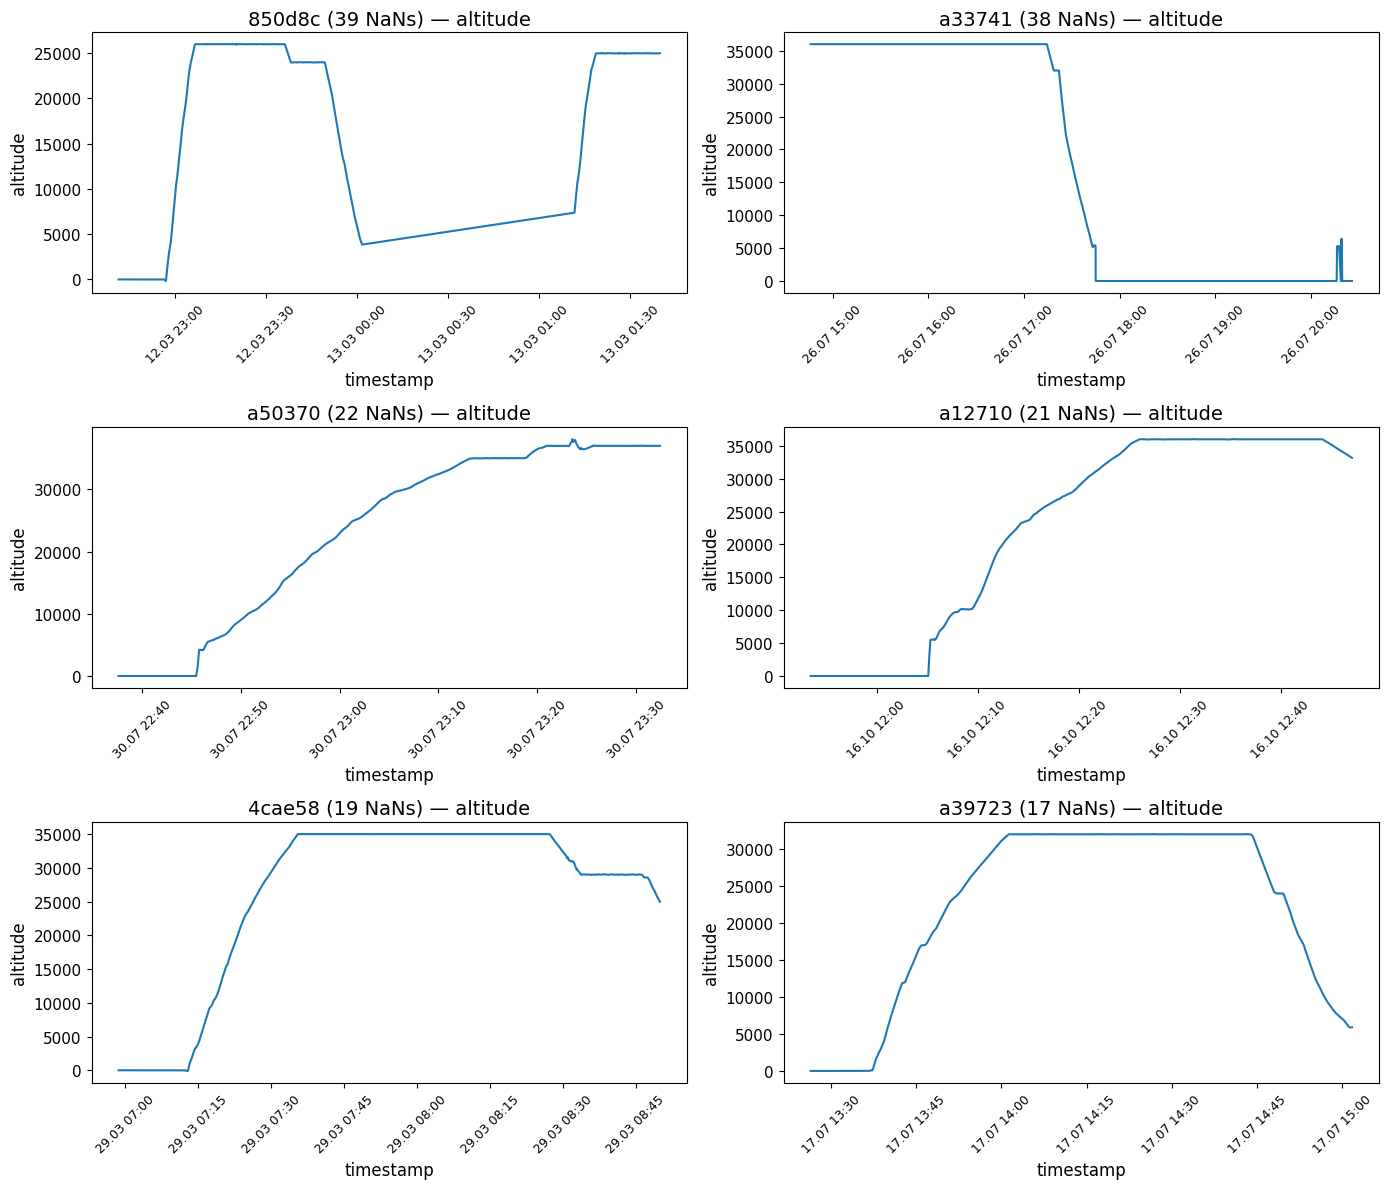

In [284]:
plot_top_icao(df_traj, top_icaos, "altitude" , "timestamp" , n = 6)

In [285]:
check_nan(df_traj)

⚠️ NaN summary:
               NaN_count NaN_percent
icao                   0       0.0 %
type                   0       0.0 %
dbFlags                0       0.0 %
timestamp              0       0.0 %
lat                    0       0.0 %
lon                    0       0.0 %
altitude               0       0.0 %
altitude_geom          0       0.0 %
ground_speed           0       0.0 %
track_degrees       1965      2.36 %
vertical_rate       6272      7.52 %
flags                  0       0.0 %
source                 0       0.0 %
h3_5                   0       0.0 %
aircraft               0       0.0 %
flight_id              0       0.0 %
t0                     0       0.0 %


In [286]:
df_traj['flight_id'].nunique()

161

For the remaining NaN values we will apply two different strategies:

- `track_degrees` (~1.6%): backward and forward fill, as gaps are negligible and values change slowly enough that the last known value is a reliable estimate.
- `vertical_rate` (~ 8%): linear interpolation, as a continuous physical 
  quantity (climb/sink rate), interpolating between known values is more 
  realistic than repeating the last known value.

##### Vertical Rate NaNs 

In [287]:
nan_vert = df_traj[df_traj['vertical_rate'].isna()]

In [288]:
top_icaos = nan_vert["icao"].value_counts().head(10)
top_icaos

icao
a33741    885
850d8c    264
7c7aae    192
a12710    187
a8f3c5    181
abb59f    174
4b17ff    167
a8d4cc    167
4cae58    162
a02dda    162
Name: count, dtype: int64

In [289]:
print(nan_vert["icao"].value_counts().info())

<class 'pandas.Series'>
Index: 123 entries, a33741 to e49b02
Series name: count
Non-Null Count  Dtype
--------------  -----
123 non-null    int64
dtypes: int64(1)
memory usage: 1.9+ KB
None


We have 123 ICAOs with missing NaNs in vertical rate

In [290]:
df_traj['vertical_rate'].isna().sum()/len(df_traj) * 100


np.float64(7.51975253875574)

We have around 8% of NaN values in this column

In [291]:
no_icao = df_traj.groupby("icao")["vertical_rate"].apply(lambda x: x.isna().all())
print(f"ICАOs with no vertical_rate values at all: {no_icao[no_icao].index.tolist()}")
print(f"Count: {no_icao.sum()}")

ICАOs with no vertical_rate values at all: ['a6456d']
Count: 1


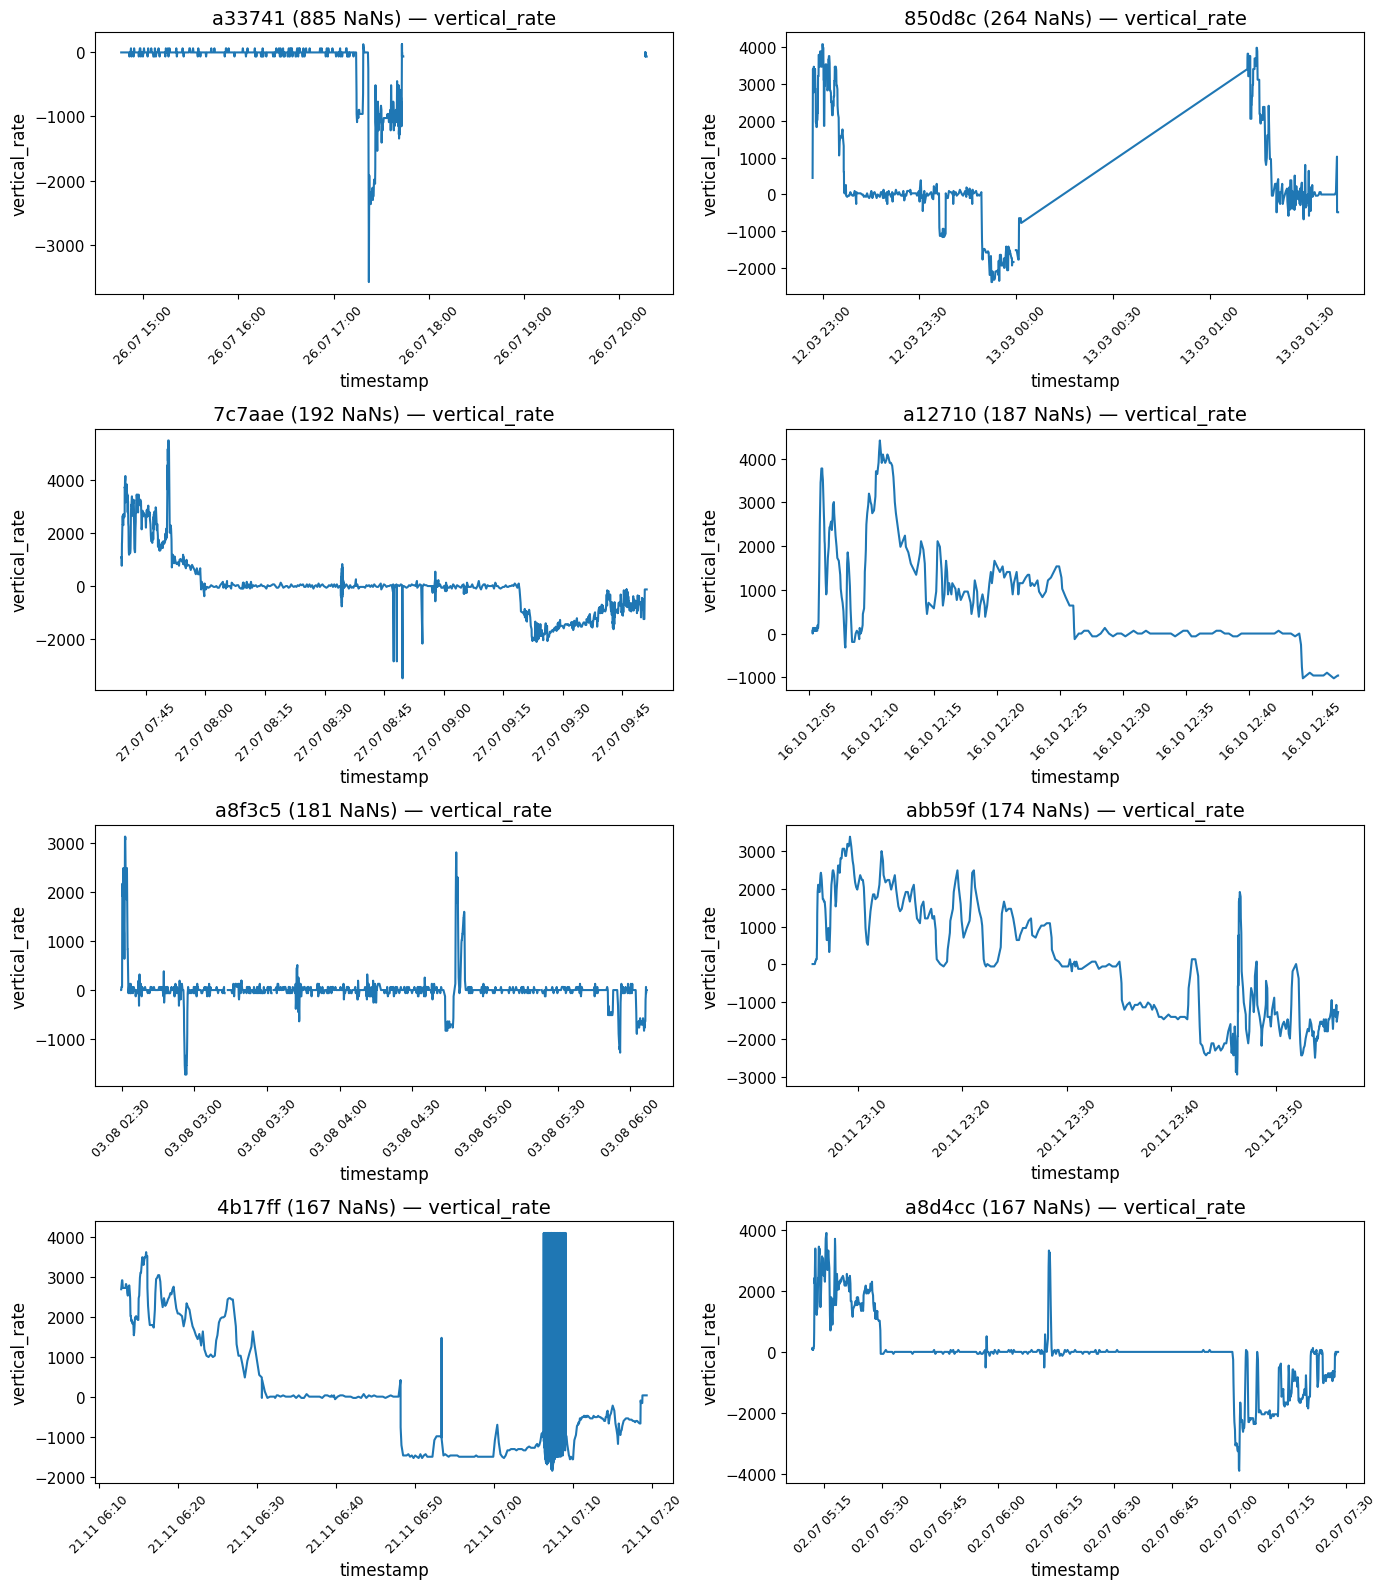

In [292]:
plot_top_icao(df_traj, top_icaos, "vertical_rate", "timestamp")

We will use Linear Interpolation as imputation

In [293]:
df_traj['vertical_rate'] = df_traj.groupby('icao')['vertical_rate'].transform(
    lambda x: x.interpolate(method='linear')
)

In [294]:
df_traj['vertical_rate'].isna().sum()/len(df_traj) * 100

np.float64(4.77777644562207)

In [295]:
df_traj['vertical_rate'] = df_traj.groupby('icao')['vertical_rate'].transform('ffill')

In [296]:
df_traj['vertical_rate'].isna().sum()/len(df_traj) * 100

np.float64(4.77777644562207)

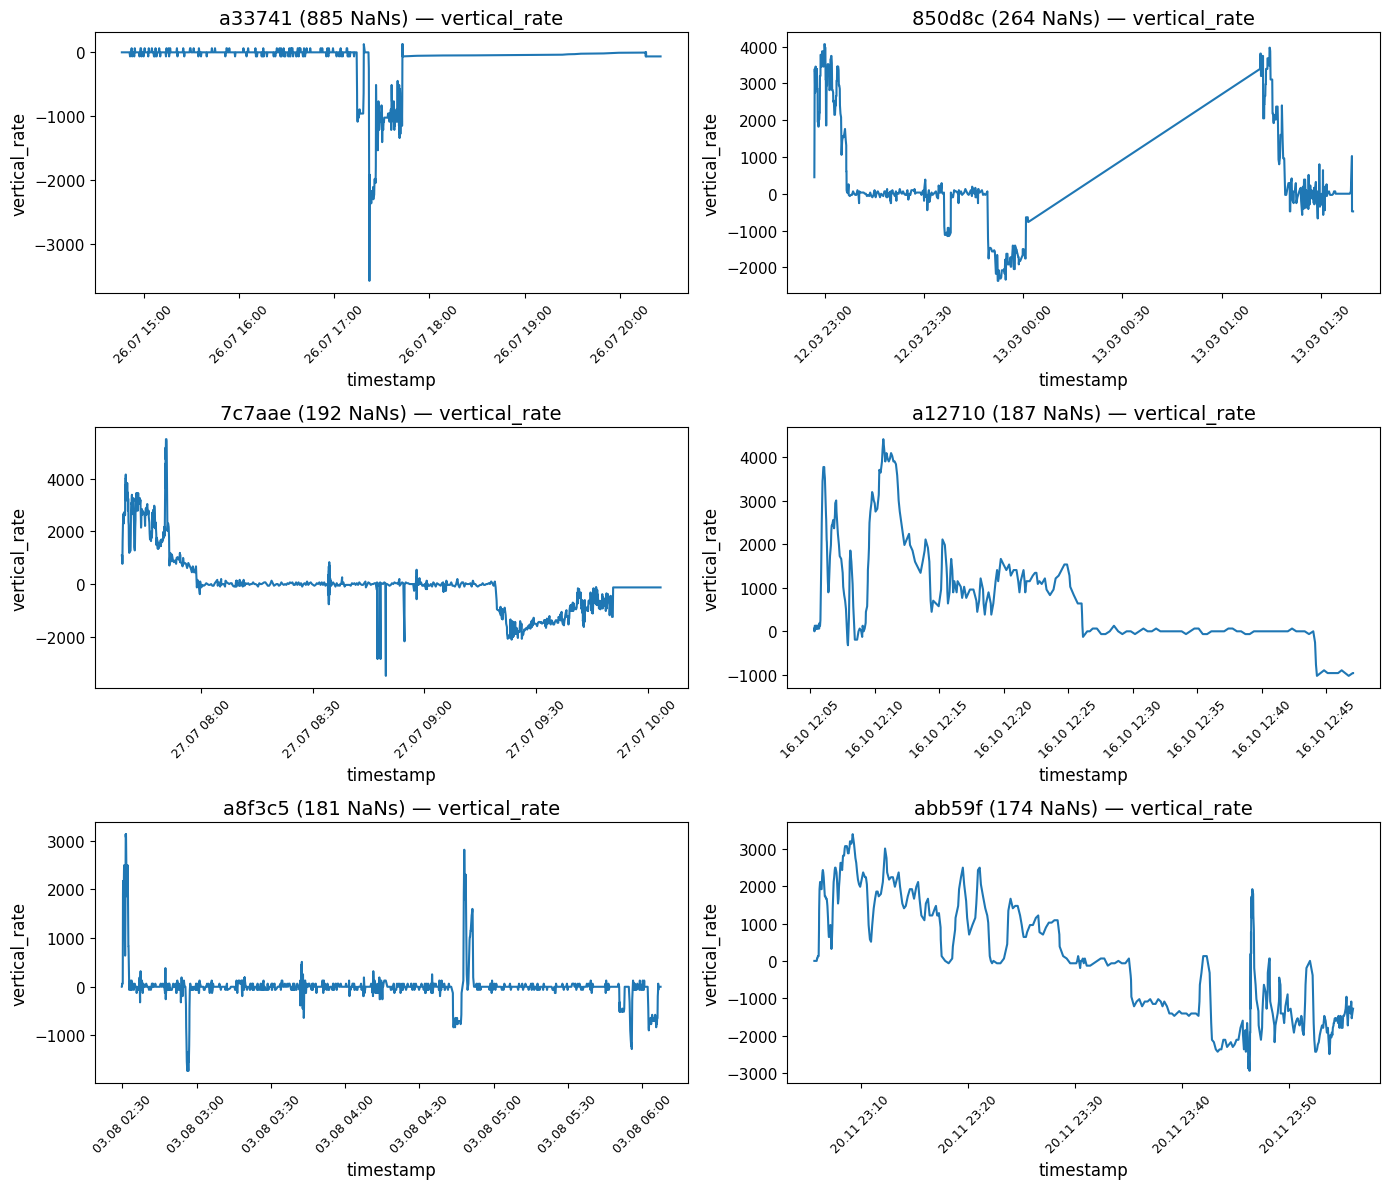

In [297]:
plot_top_icao(df_traj, top_icaos, "vertical_rate" , "timestamp", n= 6)

In [298]:
no_icao = df_traj.groupby("icao")["vertical_rate"].apply(lambda x: x.isna().all())
print(f"ICАOs with no vertical_rate values at all: {no_icao[no_icao].index.tolist()}")
print(f"Count: {no_icao.sum()}")

ICАOs with no vertical_rate values at all: ['a6456d']
Count: 1


Let's plot the altitude of this flight

In [299]:
print(df_traj[df_traj["icao"] == "a6456d"].shape[0])
print(df_traj[df_traj["icao"] == "a6456d"]["altitude"].describe())

134
count     134.000000
mean      349.253731
std       750.513235
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1950.000000
Name: altitude, dtype: float64


<Axes: title={'center': 'a6456d - altitude'}, xlabel='timestamp'>

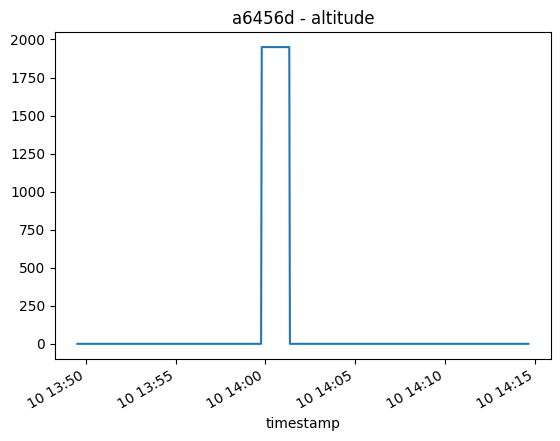

In [300]:
df_traj[df_traj["icao"] == "a6456d"].set_index("timestamp")["altitude"].plot(title="a6456d - altitude")

We will keep this ICAO, it looks like a crash. Approximates vertical rate (ft/min) from altitude differences, assuming ~1s sampling. This is a rough estimate only, not exact.

In [301]:
# vertical_rate ≈ d(altitude)/dt
df_traj.loc[df_traj["icao"] == "a6456d", "vertical_rate"] = (
    df_traj.loc[df_traj["icao"] == "a6456d", "altitude"].diff() * 60  # ft/min
)

Let's look at the remaning NaNs in vertical rate

In [302]:
print(df_traj[df_traj["vertical_rate"].isna()][["icao", "altitude", "vertical_rate"]])

         icao  altitude  vertical_rate
4227   3c5427       0.0            NaN
4228   3c5427       0.0            NaN
4229   3c5427       0.0            NaN
4230   3c5427       0.0            NaN
4231   3c5427       0.0            NaN
...       ...       ...            ...
83591  c080a6       0.0            NaN
83592  c080a6       0.0            NaN
83593  c080a6      50.0            NaN
83594  c080a6     100.0            NaN
83595  c080a6     150.0            NaN

[3852 rows x 3 columns]


The total amount is small in the context of our large dataset. The remaning NaNs in vertical rate will be filled with 0.

In [303]:
df_traj["vertical_rate"] = df_traj["vertical_rate"].fillna(0)

In [304]:
df_traj['vertical_rate'].isna().sum()/len(df_traj) * 100

np.float64(0.0)

##### Track Degrees NaNs

In [305]:
nan_tg = df_traj[df_traj['track_degrees'].isna()]

In [306]:
top_icaos = nan_tg["icao"].value_counts().head(10)
top_icaos

icao
70a9f6    702
850d8c    263
7c7aae    192
868041    152
84c586    101
7c6dba     61
a33741     59
e49b02     43
4ca9aa     19
a41144     18
Name: count, dtype: int64

In [307]:
print(nan_tg["icao"].value_counts().info())

<class 'pandas.Series'>
Index: 108 entries, 70a9f6 to e495a7
Series name: count
Non-Null Count  Dtype
--------------  -----
108 non-null    int64
dtypes: int64(1)
memory usage: 1.7+ KB
None


We have 108 ICAOs with missing NaNs in trackl degrees.

In [308]:
all_nan_track = df_traj.groupby("icao")["track_degrees"].apply(lambda x: x.isna().all())
print(f"ICАOs with no track_degrees values at all: {all_nan_track[all_nan_track].index.tolist()}")
print(f"Count: {all_nan_track.sum()}")

ICАOs with no track_degrees values at all: ['84c586', 'e49b02']
Count: 2


In [309]:
df_traj['track_degrees'].isna().sum()/len(df_traj) * 100

np.float64(2.3559173690457635)

We have around 2% of NaN values in this column

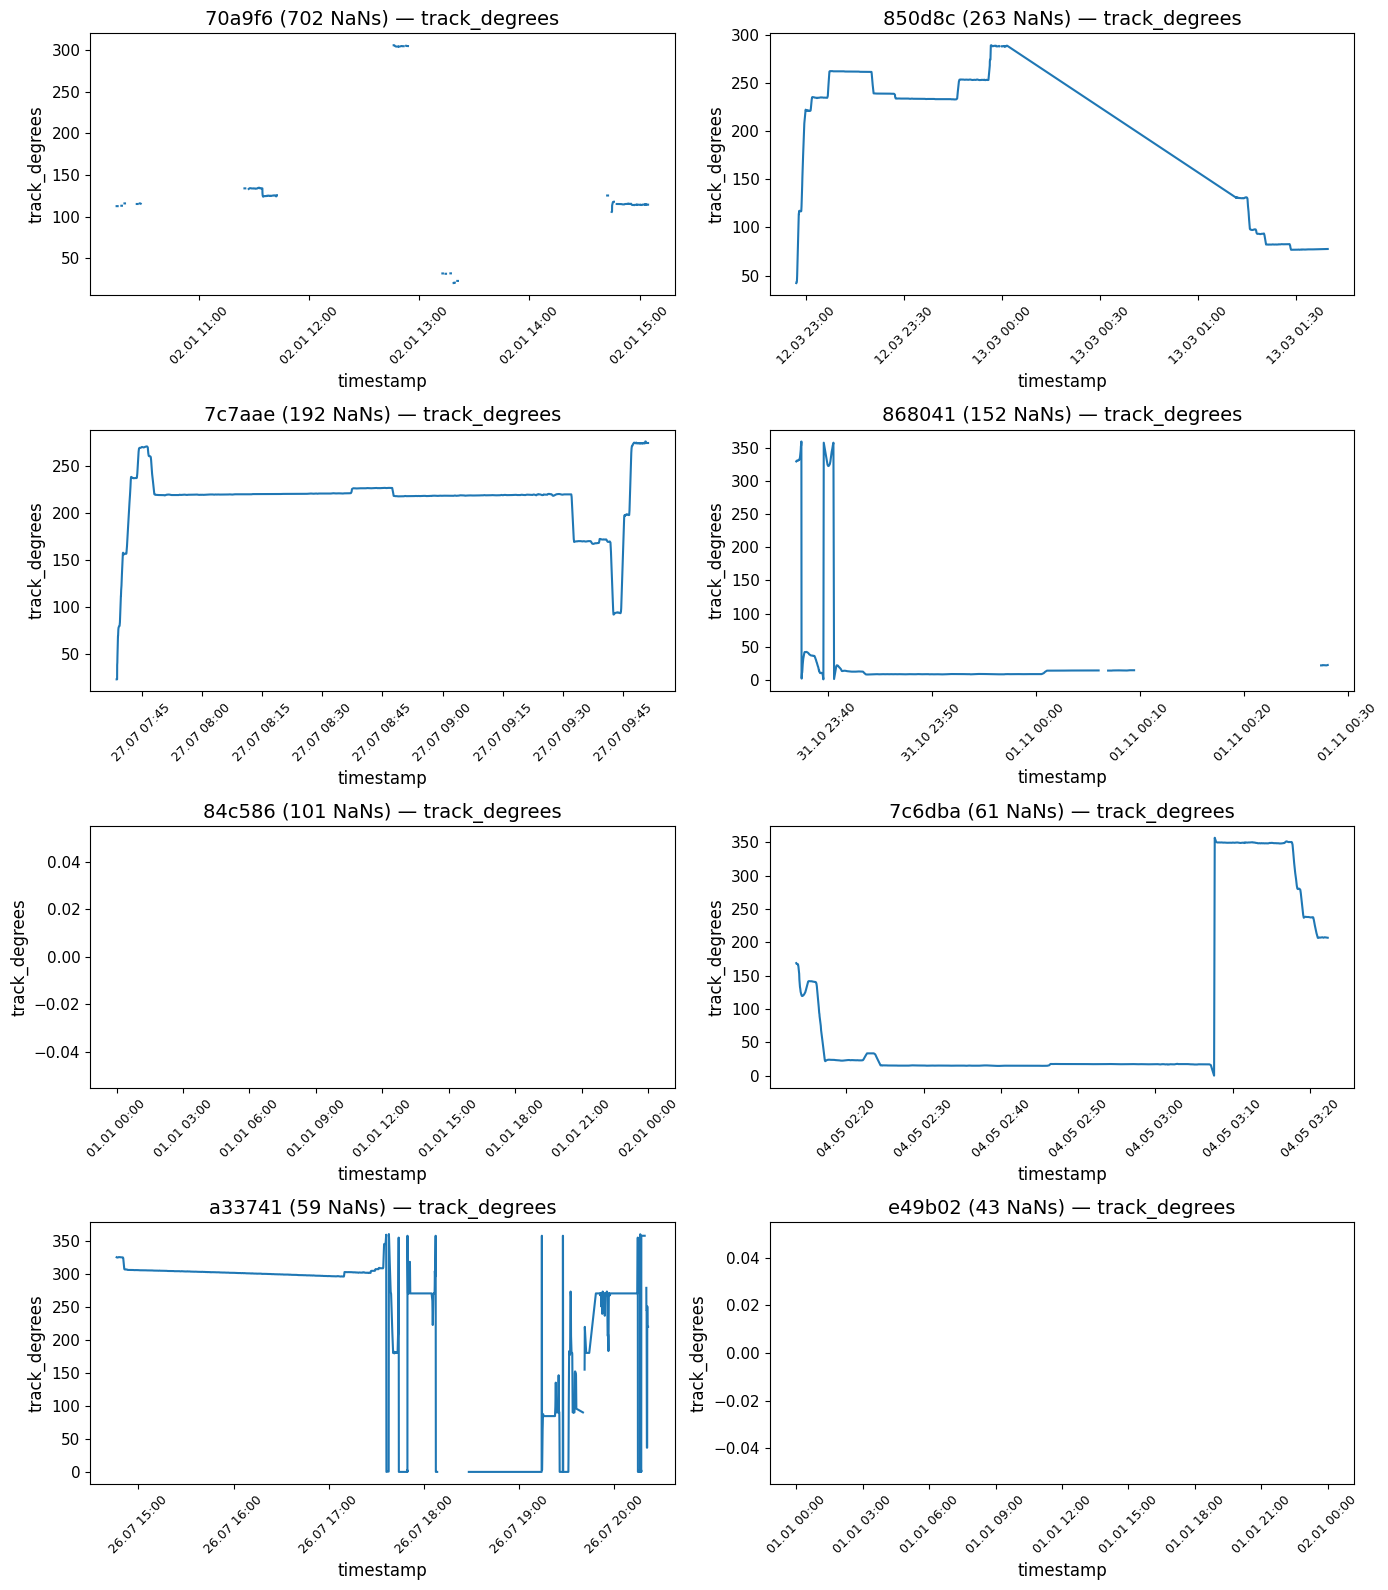

In [310]:
plot_top_icao(df_traj, top_icaos, "track_degrees", "timestamp")

Fill missing values in track_degrees using the calc_bearing function, which computes the compass direction (0–360°) from each point to the next using the great-circle bearing formula. It returns the track angle in degrees for every row in the group.

Soruce: https://www.movable-type.co.uk/scripts/latlong.html

In [311]:
from src.traces.calc_bearing import *

In [312]:
mask = df_traj['track_degrees'].isna()
df_traj.loc[mask, 'track_degrees'] = df_traj.groupby('icao', group_keys=False).apply(calc_bearing)[mask]

In [313]:
df_traj['track_degrees'].isna().sum()/len(df_traj) * 100

np.float64(0.020381982327622384)

Imputation with ffill and bfil for the remaining NaNs in track degrees

In [ ]:
# Forward and Backward fill 
df_traj['track_degrees'] = df_traj.groupby('icao')['track_degrees'].transform('ffill')
#.groupby(df_traj['icao']).transform('bfill')

In [240]:
df_traj['track_degrees'].isna().sum()/len(df_traj) * 100

np.float64(0.0)

In [241]:
check_nan(df_traj)

⚠️ NaN summary:
               NaN_count NaN_percent
icao                   0       0.0 %
type                   0       0.0 %
dbFlags                0       0.0 %
timestamp              0       0.0 %
lat                    0       0.0 %
lon                    0       0.0 %
altitude               0       0.0 %
altitude_geom          0       0.0 %
ground_speed           0       0.0 %
track_degrees          0       0.0 %
vertical_rate          0       0.0 %
flags                  0       0.0 %
source                 0       0.0 %
h3_5                   0       0.0 %
aircraft               0       0.0 %
flight_id              0       0.0 %
t0                     0       0.0 %


In [242]:
df_traj['flight_id'].nunique()

161

Let's now investiagte the object columns for nans (could be be nested data)

In [243]:
df_traj.dtypes

icao                          object
type                          object
dbFlags                        int64
timestamp        datetime64[us, UTC]
lat                          float64
lon                          float64
altitude                     float64
altitude_geom                float64
ground_speed                 float64
track_degrees                float64
vertical_rate                float64
flags                          int64
source                        object
h3_5                          object
aircraft                      object
flight_id                        str
t0               datetime64[us, UTC]
dtype: object

In [244]:
df_aircraft = pd.json_normalize(df_traj['aircraft'])
df_aircraft.head(3)

,alert,alt_geom,baro_rate,category,emergency,flight,geom_rate,gva,ias,mach,...,squawk,tas,tat,track,track_rate,true_heading,type,version,wd,ws
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [245]:
# evey column gets deleted with more than 75% NaN
drop_high_nan_columns(df_aircraft, 0.75)

Dropping 34 columns with more than 75% NaN values.
Dropped columns: ['alert', 'alt_geom', 'baro_rate', 'category', 'emergency', 'flight', 'geom_rate', 'gva', 'ias', 'mach', 'mag_heading', 'nac_p', 'nac_v', 'nav_altitude_fms', 'nav_altitude_mcp', 'nav_heading', 'nav_modes', 'nav_qnh', 'nic_baro', 'oat', 'roll', 'sda', 'sil', 'sil_type', 'spi', 'squawk', 'tas', 'tat', 'track', 'track_rate', 'true_heading', 'version', 'wd', 'ws']


,nic,rc,type
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,8.0,186.0,adsb_icao
4,NaN,NaN,NaN
...,...,...,...
84805,NaN,NaN,NaN
84806,NaN,NaN,NaN
84807,NaN,NaN,NaN
84808,8.0,186.0,adsb_icao


We see that every column in the "aircraft" nested object field has more than 75% NaNs. We will delete the "aircraft" column

In [246]:
df_traj = df = df_traj.drop(columns=['aircraft'])

In [247]:
df_traj.head(3)

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id,t0
0,00a61a,B190,0,2023-11-01 07:39:08.950000+00:00,-26.593781,27.656371,21950.0,23375.0,209.4,208.703482,64.0,4,adsb_icao,85bcc38ffffffff,00a61a_1,2023-11-01 13:09:00+00:00
1,00a61a,B190,0,2023-11-01 07:39:28.380000+00:00,-26.610535,27.646110,21925.0,23350.0,214.0,209.541534,0.0,4,adsb_icao,85bcc383fffffff,00a61a_1,2023-11-01 13:09:00+00:00
2,00a61a,B190,0,2023-11-01 07:39:48.280000+00:00,-26.627701,27.635227,21950.0,23375.0,215.9,209.522674,-64.0,4,adsb_icao,85bcc383fffffff,00a61a_1,2023-11-01 13:09:00+00:00


In [248]:
df_traj.dtypes

icao                          object
type                          object
dbFlags                        int64
timestamp        datetime64[us, UTC]
lat                          float64
lon                          float64
altitude                     float64
altitude_geom                float64
ground_speed                 float64
track_degrees                float64
vertical_rate                float64
flags                          int64
source                        object
h3_5                          object
flight_id                        str
t0               datetime64[us, UTC]
dtype: object

In [249]:
df_traj['flight_id'] = df_traj['icao']

#### Export Datasets

Let's now export our cleaned traces dataframe

In [250]:
df_traj['flight_id'].nunique()

161

In [251]:
export_df(df_traj, PROCESSED_DIR, "accidents_traces.csv")

We will export our accident metadata with the ICAOs left in our traces dataset

In [132]:
valid_icaos = df_traj["icao"].unique()
asn_accidents_filtered = asn_accidents_filtered[asn_accidents_filtered["icao"].isin(valid_icaos)]

In [133]:
asn_accidents_filtered.columns

Index(['date', 'date_utc', 'time', 'time_utc', 'type', 'owner/operator',
       'icao', 'registration', 'msn', 'year of manufacture', 'engine model',
       'fatalities', 'other fatalities', 'aircraft damage', 'category',
       'location_country', 'location', 'phase', 'nature', 'departure airport',
       'destination airport', 'investigating agency', 'confidence rating',
       'narrative', 'record_id', 'record_url', 'total airframe hrs', 'cycles',
       'timestamp'],
      dtype='str')

In [134]:
export_df(asn_accidents_filtered, PROCESSED_DIR, "asn_accident_metadata.csv")